In [21]:
import pandas as pd

# Use FULL MONTH window (not PM window) to get comprehensive electricity data
full_month_end = pd.Timestamp.now(tz="UTC").ceil("h")
full_month_start = full_month_end - pd.Timedelta(days=29)

file_path = "all_countries.csv"
keep_cols = ["Country", "ISO3 Code", "Datetime (UTC)", "Price (EUR/MWhe)"]
parts = []

for chunk in pd.read_csv(file_path, usecols=keep_cols, chunksize=500_000):
    dt = pd.to_datetime(chunk["Datetime (UTC)"], utc=True, errors="coerce")
    mask = (dt >= full_month_start) & (dt <= full_month_end)

    if mask.any():
        filtered = chunk.loc[mask].copy()
        filtered["Datetime (UTC)"] = dt.loc[mask]
        parts.append(filtered)

# Get full month of electricity data (not filtered to narrow PM window)
df_electricity_pm_window = (
    pd.concat(parts, ignore_index=True)
    if parts
    else pd.DataFrame(columns=keep_cols)
)

print("Full month window:", full_month_start, "to", full_month_end)
print("Electricity rows in full month:", df_electricity_pm_window.shape)
print(df_electricity_pm_window.head())

Full month window: 2026-02-26 12:00:00+00:00 to 2026-03-27 12:00:00+00:00
Electricity rows in full month: (17125, 4)
    Country ISO3 Code            Datetime (UTC)  Price (EUR/MWhe)
0   Austria       AUT 2026-02-26 12:00:00+00:00             21.85
1   Belgium       BEL 2026-02-26 12:00:00+00:00             10.58
2  Bulgaria       BGR 2026-02-26 12:00:00+00:00              6.62
3   Czechia       CZE 2026-02-26 12:00:00+00:00             14.95
4   Denmark       DNK 2026-02-26 12:00:00+00:00             51.73


In [38]:
# Belgium weather for FULL MONTH (hourly) using Open-Meteo
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

# Get full month window (not just PM window) for weather data
full_month_end = pd.Timestamp.now(tz="UTC").ceil("h")
full_month_start = full_month_end - pd.Timedelta(days=29)

# Resolve PM window too for reference
if "pm_hourly_last_month" in globals() and not pm_hourly_last_month.empty:
    pm_ts = pd.to_datetime(pm_hourly_last_month["timestamp"], utc=True, errors="coerce").dropna()
else:
    pm_df_tmp = pd.read_csv("pm_russia_ukraine_peace_parlay_hourly_last_month.csv")
    pm_ts = pd.to_datetime(pm_df_tmp["timestamp"], utc=True, errors="coerce").dropna()

if pm_ts.empty:
    raise ValueError("Prediction market timestamps are empty. Run the PM import cell first.")

pm_start = pm_ts.min().floor("h")
pm_end = pm_ts.max().ceil("h")

# Set up a cached + retried API client
cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Brussels proxy for Belgium - request FULL MONTH
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 50.8503,
    "longitude": 4.3517,
    "start_date": full_month_start.date().isoformat(),
    "end_date": full_month_end.date().isoformat(),
    "hourly": ["temperature_2m", "precipitation", "wind_speed_10m"],
    "timezone": "UTC",
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]
hourly = response.Hourly()

belgium_weather_hourly_pm = pd.DataFrame({
    "timestamp": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left",
    ),
    "BE Temp (C)": hourly.Variables(0).ValuesAsNumpy(),
    "BE Precipitation (mm)": hourly.Variables(1).ValuesAsNumpy(),
    "BE Wind Speed (km/h)": hourly.Variables(2).ValuesAsNumpy(),
})

# Keep FULL MONTH window (not just PM window)
belgium_weather_hourly_pm = belgium_weather_hourly_pm[
    (belgium_weather_hourly_pm["timestamp"] >= full_month_start)
    & (belgium_weather_hourly_pm["timestamp"] <= full_month_end)
].reset_index(drop=True)

print("Full month window:", full_month_start, "to", full_month_end)
print("PM window (for reference):", pm_start, "to", pm_end)
print("Weather hourly rows:", belgium_weather_hourly_pm.shape)
print(belgium_weather_hourly_pm.head())

Full month window: 2026-02-26 12:00:00+00:00 to 2026-03-27 12:00:00+00:00
PM window (for reference): 2026-02-26 11:00:00+00:00 to 2026-02-28 14:00:00+00:00
Weather hourly rows: (697, 4)
                  timestamp  BE Temp (C)  BE Precipitation (mm)  \
0 2026-02-26 12:00:00+00:00    15.850000                    0.0   
1 2026-02-26 13:00:00+00:00    16.799999                    0.0   
2 2026-02-26 14:00:00+00:00    16.950001                    0.0   
3 2026-02-26 15:00:00+00:00    16.750000                    0.0   
4 2026-02-26 16:00:00+00:00    16.200001                    0.0   

   BE Wind Speed (km/h)  
0             11.144021  
1             15.077082  
2             17.965767  
3             18.254698  
4             16.388897  


In [5]:
# PolymarketData: hourly Russia-Ukraine peace market data (last month)
from pathlib import Path
import time
import requests
import pandas as pd

api_key = Path("api.txt").read_text(encoding="utf-8").strip()
base_url = "https://api.polymarketdata.co"
headers = {"X-API-Key": api_key}


def _extract_items(payload):
    if isinstance(payload, list):
        return payload
    for key in ["data", "results", "items", "markets", "prices"]:
        if isinstance(payload, dict) and isinstance(payload.get(key), list):
            return payload[key]
    return []


def _get_with_retry(path, params=None, max_retries=8):
    url = f"{base_url}{path}"
    last_error = None
    for attempt in range(max_retries):
        r = requests.get(url, headers=headers, params=params, timeout=30)
        if r.status_code == 429:
            retry_after = r.headers.get("Retry-After")
            wait_s = float(retry_after) if retry_after else min(8 + attempt * 3, 45)
            time.sleep(wait_s)
            continue
        try:
            r.raise_for_status()
            return r.json()
        except requests.HTTPError as e:
            last_error = e
            break
    if last_error:
        raise last_error
    raise RuntimeError(f"Rate limited too many times for {path}")


def _parse_dt(value):
    if value is None:
        return pd.NaT
    return pd.to_datetime(value, utc=True, errors="coerce")


# 1) Discover Russia x Ukraine peace-like markets
now_utc = pd.Timestamp.now(tz="UTC").floor("h")
window_start = now_utc - pd.Timedelta(days=29)  # keep safely inside 30-day entitlement boundary

must_have = ["russia", "ukraine"]
optional_terms = ["peace", "ceasefire", "truce", "deal", "agreement", "war"]
scored_candidates = []
cursor = None

for _ in range(10):
    params = {"limit": 200}
    if cursor:
        params["cursor"] = cursor

    payload = _get_with_retry("/v1/markets", params=params)
    markets = _extract_items(payload)

    for m in markets:
        if not isinstance(m, dict):
            continue

        text = " ".join(
            str(m.get(k, "")) for k in ["question", "title", "name", "slug", "description"]
        ).lower()
        if not all(k in text for k in must_have):
            continue

        last_market_dt = max(
            _parse_dt(m.get("updated_at")),
            _parse_dt(m.get("closed_at")),
            _parse_dt(m.get("end_date")),
            _parse_dt(m.get("start_date")),
        )
        is_recent = pd.notna(last_market_dt) and (last_market_dt >= window_start)

        keyword_hits = sum(int(t in text) for t in optional_terms)
        active = int(bool(m.get("active") or m.get("is_active")))
        liquidity = float(m.get("liquidity") or m.get("liquidity_num") or 0)
        volume = float(m.get("volume") or m.get("volume_24h") or 0)
        recency = int(is_recent)
        scored_candidates.append((recency, keyword_hits, active, liquidity, volume, m))

    meta = payload.get("metadata", {}) if isinstance(payload, dict) else {}
    cursor = meta.get("next_cursor")
    if not cursor:
        break

    time.sleep(6.2)

if not scored_candidates:
    raise ValueError("No market containing both 'Russia' and 'Ukraine' found in scanned pages.")

# Prefer recent + relevant + liquid markets
scored_candidates.sort(reverse=True, key=lambda x: (x[0], x[1], x[2], x[3], x[4]))
candidate_markets = [x[5] for x in scored_candidates[:15]]

# 2) Pull hourly history for last month and keep first candidate with non-empty rows
common_params = {
    "start_ts": window_start.isoformat().replace("+00:00", "Z"),
    "end_ts": now_utc.isoformat().replace("+00:00", "Z"),
    "resolution": "1h",
}

selected_market = None
pm_hourly_last_month = None
source_used = None

for cand in candidate_markets:
    market_id = str(cand.get("id"))

    try:
        price_payload = _get_with_retry(f"/v1/markets/{market_id}/prices", params=common_params)
        df = pd.DataFrame(_extract_items(price_payload))
    except requests.HTTPError:
        continue

    if not df.empty:
        selected_market = cand
        pm_hourly_last_month = df
        source_used = "market_prices"
        break

    time.sleep(0.8)

# If none returned rows, keep the top candidate and return empty frame with context
if pm_hourly_last_month is None:
    selected_market = candidate_markets[0]
    pm_hourly_last_month = pd.DataFrame()
    source_used = "market_prices_empty_window"

# Normalize timestamp column if present
ts_col = next((c for c in ["timestamp", "ts", "time", "datetime", "date"] if c in pm_hourly_last_month.columns), None)
if ts_col:
    pm_hourly_last_month[ts_col] = pd.to_datetime(pm_hourly_last_month[ts_col], utc=True, errors="coerce")

print("Selected market:", selected_market.get("question") or selected_market.get("title") or selected_market.get("slug"))
print("Market id:", selected_market.get("id"))
print("Data source used:", source_used)
print("Rows:", pm_hourly_last_month.shape)
print(pm_hourly_last_month.head())
if pm_hourly_last_month.empty:
    print("No hourly rows were returned in the last-month window for matched candidates under current API entitlements.")

Selected market: Ukraine signs peace deal with Russia by June 30?
Market id: 956449
Data source used: market_prices_empty_window
Rows: (0, 0)
Empty DataFrame
Columns: []
Index: []
No hourly rows were returned in the last-month window for matched candidates under current API entitlements.


In [6]:
# Load Polymarket hourly data from saved CSV (no API call)
from pathlib import Path
import pandas as pd

pm_csv_path = Path("pm_russia_ukraine_peace_parlay_hourly_last_month.csv")
if not pm_csv_path.exists():
    raise FileNotFoundError(f"Saved Polymarket CSV not found: {pm_csv_path}")

pm_hourly_last_month_retry2 = pd.read_csv(pm_csv_path)

# Normalize/standardize timestamp column for downstream merges
ts_col = next((c for c in ["timestamp", "ts", "time", "datetime", "date"] if c in pm_hourly_last_month_retry2.columns), None)
if ts_col is None:
    raise ValueError("CSV must contain one of: timestamp, ts, time, datetime, date")

pm_hourly_last_month_retry2[ts_col] = pd.to_datetime(
    pm_hourly_last_month_retry2[ts_col], utc=True, errors="coerce"
 )
if ts_col != "timestamp":
    pm_hourly_last_month_retry2 = pm_hourly_last_month_retry2.rename(columns={ts_col: "timestamp"})

pm_hourly_last_month_retry2 = (
    pm_hourly_last_month_retry2
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# Optional compatibility variables
selected_market_retry2 = {
    "id": "csv_local_file",
    "question": "Russia x Ukraine Peace Parlay (from saved CSV)",
}
candidates = [selected_market_retry2]
attempt_log2 = [("csv_local_file", pm_csv_path.name, len(pm_hourly_last_month_retry2))]

print("Candidates found:", len(candidates))
print("Top attempted (id, question, status/rows):")
for row in attempt_log2:
    print(row)

print("\nSelected market:", selected_market_retry2.get("question"))
print("Rows:", pm_hourly_last_month_retry2.shape)
print(pm_hourly_last_month_retry2.head())

Candidates found: 1
Top attempted (id, question, status/rows):
('csv_local_file', 'pm_russia_ukraine_peace_parlay_hourly_last_month.csv', 50)

Selected market: Russia x Ukraine Peace Parlay (from saved CSV)
Rows: (50, 3)
                  timestamp  price_No  price_Yes
0 2026-02-24 13:00:00+00:00     0.755      0.245
1 2026-02-24 14:00:00+00:00     0.755      0.245
2 2026-02-24 15:00:00+00:00     0.755      0.245
3 2026-02-24 16:00:00+00:00     0.755      0.245
4 2026-02-24 17:00:00+00:00     0.755      0.245


In [7]:
# Debug payload shape for a known market title
import json
import requests
import pandas as pd
from pathlib import Path

api_key = Path("api.txt").read_text(encoding="utf-8").strip()
headers = {"X-API-Key": api_key}

market_id = "694027"  # Russia x Ukraine Peace Parlay
end_ts = pd.Timestamp.now(tz="UTC").floor("h")
start_ts = end_ts - pd.Timedelta(days=29)

resp = requests.get(
    f"https://api.polymarketdata.co/v1/markets/{market_id}/prices",
    headers=headers,
    params={
        "start_ts": start_ts.isoformat().replace("+00:00", "Z"),
        "end_ts": end_ts.isoformat().replace("+00:00", "Z"),
        "resolution": "1h",
    },
    timeout=30,
)

print("status:", resp.status_code)
body = resp.json()
print("type:", type(body))
if isinstance(body, dict):
    print("keys:", list(body.keys()))
    for k in ["data", "prices", "results", "items"]:
        v = body.get(k)
        if isinstance(v, list):
            print(f"{k} rows:", len(v))
        elif isinstance(v, dict):
            print(f"{k} keys:", list(v.keys())[:10])

print("raw preview:")
print(json.dumps(body, indent=2)[:1500])

status: 200
type: <class 'dict'>
keys: ['market_id', 'resolution', 'tokens', 'data', 'metadata']
data keys: ['No', 'Yes']
raw preview:
{
  "market_id": "694027",
  "resolution": "1h",
  "tokens": {
    "No": "51164266914155164078894125458599944121164000045642724059217688177813405604759",
    "Yes": "22812895764648101937611607427223609714680609990042020918357037515389986407242"
  },
  "data": {
    "No": [
      {
        "t": "2026-02-26T11:00:00",
        "p": 0.7649999999999999
      },
      {
        "t": "2026-02-26T12:00:00",
        "p": 0.7605263157894737
      },
      {
        "t": "2026-02-26T13:00:00",
        "p": 0.76
      },
      {
        "t": "2026-02-26T14:00:00",
        "p": 0.76
      },
      {
        "t": "2026-02-26T15:00:00",
        "p": 0.76
      },
      {
        "t": "2026-02-26T16:00:00",
        "p": 0.76
      },
      {
        "t": "2026-02-26T17:00:00",
        "p": 0.76
      },
      {
        "t": "2026-02-26T18:00:00",
        "p": 0.76
    

In [18]:
# Final: import hourly data for a Russia-Ukraine peace/ceasefire market (last month)
from pathlib import Path
import time
import requests
import pandas as pd

api_key = Path("api.txt").read_text(encoding="utf-8").strip()
base_url = "https://api.polymarketdata.co"
headers = {"X-API-Key": api_key}


def get_json(path, params=None, retries=8):
    url = f"{base_url}{path}"
    for i in range(retries):
        r = requests.get(url, headers=headers, params=params, timeout=30)
        if r.status_code == 429:
            time.sleep(min(float(r.headers.get("Retry-After", 8 + 2 * i)), 45))
            continue
        r.raise_for_status()
        return r.json()
    raise RuntimeError("Rate-limited too many times")


def parse_market_prices(payload):
    # API shape: data is nested by outcome, e.g. data.Yes / data.No arrays of {t, p}
    if not isinstance(payload, dict):
        return pd.DataFrame()

    data = payload.get("data")
    if isinstance(data, dict):
        series = []
        for outcome, rows in data.items():
            if not isinstance(rows, list):
                continue
            part = pd.DataFrame(rows)
            if part.empty or "t" not in part.columns or "p" not in part.columns:
                continue
            part = part.rename(columns={"t": "timestamp", "p": f"price_{outcome}"})
            part["timestamp"] = pd.to_datetime(part["timestamp"], utc=True, errors="coerce")
            series.append(part[["timestamp", f"price_{outcome}"]])

        if not series:
            return pd.DataFrame()

        out = series[0]
        for part in series[1:]:
            out = out.merge(part, on="timestamp", how="outer")
        return out.sort_values("timestamp", ignore_index=True)

    return pd.DataFrame()


# 1) Candidate market IDs
# 694027 was discovered in this notebook as: "Russia x Ukraine Peace Parlay"
candidate_ids = ["694027", "956449", "394050"]

# 2) Pull last-month hourly prices from first candidate with non-empty rows
end_ts = pd.Timestamp.now(tz="UTC").floor("h")
start_ts = end_ts - pd.Timedelta(days=29)
params_hist = {
    "start_ts": start_ts.isoformat().replace("+00:00", "Z"),
    "end_ts": end_ts.isoformat().replace("+00:00", "Z"),
    "resolution": "1h",
}

selected_market = None
pm_hourly_last_month = pd.DataFrame()

for market_id in candidate_ids:
    try:
        meta = get_json(f"/v1/markets/{market_id}")
        raw = get_json(f"/v1/markets/{market_id}/prices", params=params_hist)
    except requests.HTTPError:
        continue

    df_try = parse_market_prices(raw)
    if not df_try.empty:
        selected_market = meta
        pm_hourly_last_month = df_try
        break

if pm_hourly_last_month.empty:
    raise ValueError("No hourly rows returned for candidate Russia-Ukraine peace/ceasefire markets in the last month.")

print("Market:", selected_market.get("question") or selected_market.get("slug"))
print("Market ID:", selected_market.get("id"))
print("Rows:", pm_hourly_last_month.shape)
print(pm_hourly_last_month.head())

Market: Russia x Ukraine Peace Parlay
Market ID: 694027
Rows: (50, 3)
                  timestamp  price_No  price_Yes
0 2026-02-26 11:00:00+00:00  0.765000   0.235000
1 2026-02-26 12:00:00+00:00  0.760526   0.239474
2 2026-02-26 13:00:00+00:00  0.760000   0.240000
3 2026-02-26 14:00:00+00:00  0.760000   0.240000
4 2026-02-26 15:00:00+00:00  0.760000   0.240000


In [51]:
# ====================================================
# API CAPABILITY TEST: How much hourly PM data can we extract?
# Test different resolutions, time windows, and markets
# ====================================================
import requests
import pandas as pd
import time
from pathlib import Path

api_key = Path("api.txt").read_text(encoding="utf-8").strip()
base_url = "https://api.polymarketdata.co"
headers = {"X-API-Key": api_key}

def get_json_safe(path, params=None, retries=3):
    """Safely fetch JSON with rate limit handling"""
    url = f"{base_url}{path}"
    for i in range(retries):
        try:
            r = requests.get(url, headers=headers, params=params, timeout=30)
            if r.status_code == 429:
                wait_time = min(float(r.headers.get("Retry-After", 8 + 2 * i)), 45)
                print(f"Rate limited, waiting {wait_time}s")
                time.sleep(wait_time)
                continue
            if r.status_code != 200:
                print(f"Status {r.status_code}: {r.text[:200]}")
                return None
            return r.json()
        except Exception as e:
            print(f"Error: {e}")
            return None
    return None

# Test 1: Check market metadata and creation date
print("=" * 80)
print("TEST 1: Market metadata for Russia-Ukraine Peace markets")
print("=" * 80)

candidate_ids = ["694027", "956449", "394050"]
market_info = {}

for market_id in candidate_ids:
    meta = get_json_safe(f"/v1/markets/{market_id}")
    if meta:
        market_info[market_id] = {
            "slug": meta.get("slug"),
            "question": meta.get("question"),
            "created_at": meta.get("created_at"),
            "resolution": meta.get("resolution"),
            "expires": meta.get("expires_on"),
        }
        print(f"\nMarket {market_id}:")
        print(f"  Question: {meta.get('question')[:80]}")
        print(f"  Created: {meta.get('created_at')}")
        print(f"  Expires: {meta.get('expires_on')}")
        print(f"  Active: {meta.get('active')}")

# Test 2: Try different resolutions
print("\n" + "=" * 80)
print("TEST 2: Data availability by resolution (1h vs 1m)")
print("=" * 80)

end_ts = pd.Timestamp.now(tz="UTC").floor("h")
start_ts = end_ts - pd.Timedelta(days=29)

for resolution in ["1h", "1m"]:
    params = {
        "start_ts": start_ts.isoformat().replace("+00:00", "Z"),
        "end_ts": end_ts.isoformat().replace("+00:00", "Z"),
        "resolution": resolution,
    }
    
    raw = get_json_safe(f"/v1/markets/694027/prices", params=params)
    
    if raw and raw.get("data"):
        data = raw["data"]
        # Count total data points
        total_count = 0
        for outcome, rows in data.items():
            if isinstance(rows, list):
                total_count += len(rows)
                print(f"  {resolution}: {outcome} -> {len(rows)} points")
        print(f"  {resolution}: Total = {total_count} points (theoretical max: {int((end_ts - start_ts).total_seconds() / pd.Timedelta(resolution).total_seconds())})")
    else:
        print(f"  {resolution}: No data returned")

# Test 3: Try different time windows
print("\n" + "=" * 80)
print("TEST 3: Data by time window (last 3, 7, 14, 29 days)")
print("=" * 80)

for days in [3, 7, 14, 29]:
    window_start = end_ts - pd.Timedelta(days=days)
    params = {
        "start_ts": window_start.isoformat().replace("+00:00", "Z"),
        "end_ts": end_ts.isoformat().replace("+00:00", "Z"),
        "resolution": "1h",
    }
    
    raw = get_json_safe(f"/v1/markets/694027/prices", params=params)
    
    if raw and raw.get("data"):
        data = raw["data"]
        total_count = sum(len(rows) if isinstance(rows, list) else 0 for rows in data.values())
        print(f"  Last {days} days: {total_count} hourly observations")

# Test 4: Check if minute-level data exists and calculate aggregated hourly
print("\n" + "=" * 80)
print("TEST 4: Minute-level data to hourly aggregation")
print("=" * 80)

window_start = end_ts - pd.Timedelta(days=7)  # Just last 7 days for speed
params = {
    "start_ts": window_start.isoformat().replace("+00:00", "Z"),
    "end_ts": end_ts.isoformat().replace("+00:00", "Z"),
    "resolution": "1m",
}

raw = get_json_safe(f"/v1/markets/694027/prices", params=params)

if raw and raw.get("data"):
    data = raw["data"]
    total_minute_count = sum(len(rows) if isinstance(rows, list) else 0 for rows in data.values())
    theoretical_hourly = total_minute_count // 60
    print(f"  Minute-level data: {total_minute_count} points")
    print(f"  Can aggregate to: ~{theoretical_hourly} hourly observations")
    print(f"  Data density: {(total_minute_count / (7 * 24 * 60)):.1%} (7-day window)")
else:
    print(f"  Minute-level data: Not available")

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"Current setup using 694027 ({market_info.get('694027', {}).get('question', 'Unknown')[:60]})")
print(f"Time window: {(end_ts - start_ts).days} days")
print(f"Format: Hourly only")
print(f"Max potential rows: ~{(end_ts - start_ts).days * 24}")
print(f"Current actual rows: Check cell output above")

TEST 1: Market metadata for Russia-Ukraine Peace markets

Market 694027:
  Question: Russia x Ukraine Peace Parlay
  Created: None
  Expires: None
  Active: None

Market 956449:
  Question: Ukraine signs peace deal with Russia by June 30?
  Created: None
  Expires: None
  Active: None
Status 404: {"detail":"Market not found: 394050","request_id":"92b524a7-b022-4c54-8dda-ccc656b524b6"}

TEST 2: Data availability by resolution (1h vs 1m)
  1h: No -> 50 points
  1h: Yes -> 50 points
  1h: Total = 100 points (theoretical max: 696)
Status 403: {"detail":"Your plan does not allow 1m granularity. Minimum allowed: 10m","request_id":"f18a2809-3313-47b5-8980-a7b6047f74f9"}
  1m: No data returned

TEST 3: Data by time window (last 3, 7, 14, 29 days)
  Last 3 days: 100 hourly observations
  Last 7 days: 100 hourly observations
  Last 14 days: 100 hourly observations
  Last 29 days: 100 hourly observations

TEST 4: Minute-level data to hourly aggregation
Status 403: {"detail":"Your plan does not al

In [52]:
# Build explicit 100-observation PM extract (long format) and 50-timestamp wide format
import pandas as pd
import requests
from pathlib import Path

api_key = Path("api.txt").read_text(encoding="utf-8").strip()
headers = {"X-API-Key": api_key}

market_id = "694027"
end_ts = pd.Timestamp.now(tz="UTC").floor("h")
start_ts = end_ts - pd.Timedelta(days=29)

params = {
    "start_ts": start_ts.isoformat().replace("+00:00", "Z"),
    "end_ts": end_ts.isoformat().replace("+00:00", "Z"),
    "resolution": "1h",
}

resp = requests.get(
    f"https://api.polymarketdata.co/v1/markets/{market_id}/prices",
    headers=headers,
    params=params,
    timeout=30,
)
resp.raise_for_status()
payload = resp.json()

if not isinstance(payload, dict) or not isinstance(payload.get("data"), dict):
    raise ValueError("Unexpected API payload shape for market prices.")

# Long format: keep each outcome point as its own observation (target: 100 obs)
long_parts = []
for outcome, rows in payload["data"].items():
    if not isinstance(rows, list):
        continue
    part = pd.DataFrame(rows)
    if part.empty or "t" not in part.columns or "p" not in part.columns:
        continue
    part = part.rename(columns={"t": "timestamp", "p": "price"})
    part["timestamp"] = pd.to_datetime(part["timestamp"], utc=True, errors="coerce")
    part["outcome"] = str(outcome)
    long_parts.append(part[["timestamp", "outcome", "price"]])

if not long_parts:
    raise ValueError("No outcome series returned by API.")

pm_long_100 = pd.concat(long_parts, ignore_index=True).dropna(subset=["timestamp", "price"])
pm_long_100 = pm_long_100.sort_values(["timestamp", "outcome"]).reset_index(drop=True)

# Wide format for existing pipeline (typically 50 timestamps)
pm_wide = (
    pm_long_100
    .pivot_table(index="timestamp", columns="outcome", values="price", aggfunc="last")
    .reset_index()
    .rename(columns={"Yes": "price_Yes", "No": "price_No"})
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# Save both raw extract and pipeline-ready extract
pm_long_csv = "pm_russia_ukraine_peace_parlay_hourly_last_month_long_100obs.csv"
pm_wide_csv = "pm_russia_ukraine_peace_parlay_hourly_last_month_wide.csv"
pm_long_100.to_csv(pm_long_csv, index=False)
pm_wide.to_csv(pm_wide_csv, index=False)

# Update in-memory dataframe used by downstream cells
pm_hourly_last_month = pm_wide.copy()

print("Saved:", pm_long_csv, "| rows:", pm_long_100.shape)
print("Saved:", pm_wide_csv, "| rows:", pm_wide.shape)
print("Outcome counts:")
print(pm_long_100["outcome"].value_counts())
print("Timestamp coverage:", pm_wide["timestamp"].min(), "to", pm_wide["timestamp"].max())

Saved: pm_russia_ukraine_peace_parlay_hourly_last_month_long_100obs.csv | rows: (100, 3)
Saved: pm_russia_ukraine_peace_parlay_hourly_last_month_wide.csv | rows: (50, 3)
Outcome counts:
outcome
No     50
Yes    50
Name: count, dtype: int64
Timestamp coverage: 2026-02-26 12:00:00+00:00 to 2026-02-28 15:00:00+00:00


In [53]:
# Save prediction-market hourly data, then build an hourly aligned dataset spanning full month
# 1) Save PM hourly data for safekeeping
pm_csv_path = "pm_russia_ukraine_peace_parlay_hourly_last_month.csv"
pm_hourly_last_month.to_csv(pm_csv_path, index=False)

if "timestamp" not in pm_hourly_last_month.columns:
    raise ValueError("pm_hourly_last_month must contain a 'timestamp' column.")

pm_hourly_last_month["timestamp"] = pd.to_datetime(pm_hourly_last_month["timestamp"], utc=True, errors="coerce")
pm_hourly_last_month = pm_hourly_last_month.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

# Use full month window for electricity/weather (not just PM available window)
full_month_start = pd.Timestamp.now(tz="UTC").floor("h") - pd.Timedelta(days=29)
full_month_end = pd.Timestamp.now(tz="UTC").ceil("h")

# 2) Build hourly electricity features from FULL MONTH (not just PM window)
energy_hourly = df_electricity_pm_window.copy()
energy_hourly["timestamp"] = pd.to_datetime(energy_hourly["Datetime (UTC)"], utc=True, errors="coerce")
energy_hourly = energy_hourly.dropna(subset=["timestamp"])

energy_hourly_wide = (
    energy_hourly
    .pivot(index="timestamp", columns="Country", values="Price (EUR/MWhe)")
    .sort_index()
)
energy_hourly_wide = energy_hourly_wide.add_prefix("Country Hourly - ")

europe_hourly = energy_hourly_wide.mean(axis=1).rename("Europe Hourly Avg Price (EUR/MWhe)")
energy_hourly_features = pd.concat([europe_hourly, energy_hourly_wide], axis=1).reset_index()

# 3) Use hourly weather from the full month
if "belgium_weather_hourly_pm" not in globals():
    raise ValueError("Run the weather import cell to create belgium_weather_hourly_pm before this merge.")

# 4) Final aligned hourly dataset using FULL MONTH window, then left-join PM data where available
hourly_aligned = (
    energy_hourly_features[
        (energy_hourly_features["timestamp"] >= full_month_start) & 
        (energy_hourly_features["timestamp"] <= full_month_end)
    ].copy()
)

# Merge weather
hourly_aligned = hourly_aligned.merge(
    belgium_weather_hourly_pm[
        (belgium_weather_hourly_pm["timestamp"] >= full_month_start) & 
        (belgium_weather_hourly_pm["timestamp"] <= full_month_end)
    ],
    on="timestamp",
    how="left",
)

# Merge PM data (will only have rows where PM data exists)
hourly_aligned = hourly_aligned.merge(
    pm_hourly_last_month,
    on="timestamp",
    how="left",
)

hourly_aligned = hourly_aligned.sort_values("timestamp", ignore_index=True)

# Keep only relevant columns
preferred_cols = [
    "timestamp",
    "price_No",
    "price_Yes",
    "Country Hourly - Belgium",
    "BE Temp (C)",
    "BE Precipitation (mm)",
    "BE Wind Speed (km/h)",
]
existing_cols = [c for c in preferred_cols if c in hourly_aligned.columns]
hourly_aligned = hourly_aligned[existing_cols].copy()

aligned_csv_path = "hourly_aligned_with_pm_window.csv"
hourly_aligned.to_csv(aligned_csv_path, index=False)

print("Saved:", pm_csv_path)
print("Saved:", aligned_csv_path)
print("PM window:", pm_start, "to", pm_end)
print("Final columns:", hourly_aligned.columns.tolist())
print("hourly_aligned:", hourly_aligned.shape)
print(hourly_aligned.head())

Saved: pm_russia_ukraine_peace_parlay_hourly_last_month.csv
Saved: hourly_aligned_with_pm_window.csv
PM window: 2026-02-26 11:00:00+00:00 to 2026-02-28 14:00:00+00:00
Final columns: ['timestamp', 'price_No', 'price_Yes', 'Country Hourly - Belgium', 'BE Temp (C)', 'BE Precipitation (mm)', 'BE Wind Speed (km/h)']
hourly_aligned: (635, 7)
                  timestamp  price_No  price_Yes  Country Hourly - Belgium  \
0 2026-02-26 12:00:00+00:00  0.760526   0.239474                     10.58   
1 2026-02-26 13:00:00+00:00  0.760000   0.240000                     33.60   
2 2026-02-26 14:00:00+00:00  0.760000   0.240000                     54.17   
3 2026-02-26 15:00:00+00:00  0.760000   0.240000                     71.92   
4 2026-02-26 16:00:00+00:00  0.760000   0.240000                     88.44   

   BE Temp (C)  BE Precipitation (mm)  BE Wind Speed (km/h)  
0    15.850000                    0.0             11.144021  
1    16.799999                    0.0             15.077082  
2    16

In [36]:
# UTC audit + alignment for PM, electricity, and weather timestamps

def _ensure_utc(series):
    s = pd.to_datetime(series, errors="coerce")
    if getattr(s.dt, "tz", None) is None:
        return s.dt.tz_localize("UTC")
    return s.dt.tz_convert("UTC")

# Align all core timestamp columns to UTC (idempotent if already UTC)
pm_hourly_last_month["timestamp"] = _ensure_utc(pm_hourly_last_month["timestamp"])
df_electricity_pm_window["Datetime (UTC)"] = _ensure_utc(df_electricity_pm_window["Datetime (UTC)"])
belgium_weather_hourly_pm["timestamp"] = _ensure_utc(belgium_weather_hourly_pm["timestamp"])
hourly_aligned["timestamp"] = _ensure_utc(hourly_aligned["timestamp"])

# Confirm timezone status
pm_tz = str(pm_hourly_last_month["timestamp"].dt.tz)
elec_tz = str(df_electricity_pm_window["Datetime (UTC)"].dt.tz)
weather_tz = str(belgium_weather_hourly_pm["timestamp"].dt.tz)
final_tz = str(hourly_aligned["timestamp"].dt.tz)

print("PM timestamp tz:", pm_tz)
print("Electricity Datetime (UTC) tz:", elec_tz)
print("Weather timestamp tz:", weather_tz)
print("Final DF timestamp tz:", final_tz)

if not all(tz == "UTC" for tz in [pm_tz, elec_tz, weather_tz, final_tz]):
    raise ValueError("One or more timestamp columns are not UTC after alignment.")

print("All core time columns are aligned to UTC.")

PM timestamp tz: UTC
Electricity Datetime (UTC) tz: UTC
Weather timestamp tz: UTC
Final DF timestamp tz: UTC
All core time columns are aligned to UTC.


In [54]:
# Build differenced dataset: difference all series, while retaining PM prices in levels too
hourly_aligned_diff = hourly_aligned.copy().sort_values("timestamp").reset_index(drop=True)

# Numeric columns to difference
numeric_cols = [c for c in hourly_aligned_diff.columns if c != "timestamp"]

# First differences
diff_values = hourly_aligned_diff[numeric_cols].diff()
diff_values = diff_values.rename(columns={c: f"d_{c}" for c in numeric_cols})

# Keep PM prices in levels as requested
level_cols = ["timestamp", "price_No", "price_Yes"]
level_cols = [c for c in level_cols if c in hourly_aligned_diff.columns]

hourly_aligned_diff = pd.concat([
    hourly_aligned_diff[level_cols],
    diff_values,
], axis=1)

# Drop only first row with NaN diffs (from differencing), keep all others including those with NaN PM prices
# This preserves the full month of electricity/weather data while allowing sparse PM data
hourly_aligned_diff = hourly_aligned_diff.iloc[1:].reset_index(drop=True)

# Save
hourly_diff_csv_path = "hourly_aligned_with_pm_window_differences.csv"
hourly_aligned_diff.to_csv(hourly_diff_csv_path, index=False)

print("Saved:", hourly_diff_csv_path)
print("Shape:", hourly_aligned_diff.shape)
print("Rows with valid PM prices:", hourly_aligned_diff["price_No"].notna().sum())
print("Columns:", hourly_aligned_diff.columns.tolist())
print(hourly_aligned_diff.head())
print("... (middle rows omitted)")
print(hourly_aligned_diff.tail())

Saved: hourly_aligned_with_pm_window_differences.csv
Shape: (634, 9)
Rows with valid PM prices: 49
Columns: ['timestamp', 'price_No', 'price_Yes', 'd_price_No', 'd_price_Yes', 'd_Country Hourly - Belgium', 'd_BE Temp (C)', 'd_BE Precipitation (mm)', 'd_BE Wind Speed (km/h)']
                  timestamp  price_No  price_Yes  d_price_No  d_price_Yes  \
0 2026-02-26 13:00:00+00:00      0.76       0.24   -0.000526     0.000526   
1 2026-02-26 14:00:00+00:00      0.76       0.24    0.000000     0.000000   
2 2026-02-26 15:00:00+00:00      0.76       0.24    0.000000     0.000000   
3 2026-02-26 16:00:00+00:00      0.76       0.24    0.000000     0.000000   
4 2026-02-26 17:00:00+00:00      0.76       0.24    0.000000     0.000000   

   d_Country Hourly - Belgium  d_BE Temp (C)  d_BE Precipitation (mm)  \
0                       23.02       0.949999                      0.0   
1                       20.57       0.150002                      0.0   
2                       17.75      -0.2000

In [56]:
# Percentage-change dataset: put all series on a common scale (%)
# while retaining PM prices in levels
import numpy as np

hourly_aligned_pct = hourly_aligned.copy().sort_values("timestamp").reset_index(drop=True)

level_cols = [c for c in ["timestamp", "price_No", "price_Yes"] if c in hourly_aligned_pct.columns]
numeric_cols = [c for c in hourly_aligned_pct.columns if c not in level_cols]

# pct_change gives fractional changes; multiply by 100 for percent
pct_vals = hourly_aligned_pct[numeric_cols].pct_change() * 100
# Avoid pandas replace bug by masking inf values directly
pct_vals = pct_vals.mask(np.isinf(pct_vals), pd.NA)
pct_vals = pct_vals.rename(columns={c: f"pct_{c}" for c in numeric_cols})

hourly_aligned_pct = pd.concat([
    hourly_aligned_pct[level_cols],
    pct_vals,
], axis=1)

# Keep rows where at least one pct-change feature is valid
pct_cols = [c for c in hourly_aligned_pct.columns if c.startswith("pct_")]
hourly_aligned_pct = hourly_aligned_pct.dropna(how="all", subset=pct_cols).reset_index(drop=True)

hourly_pct_csv_path = "hourly_aligned_with_pm_window_pct_changes.csv"
hourly_aligned_pct.to_csv(hourly_pct_csv_path, index=False)

print("Saved:", hourly_pct_csv_path)
print("Shape:", hourly_aligned_pct.shape)
print("Columns:", hourly_aligned_pct.columns.tolist())
print(hourly_aligned_pct.head())

Saved: hourly_aligned_with_pm_window_pct_changes.csv
Shape: (634, 7)
Columns: ['timestamp', 'price_No', 'price_Yes', 'pct_Country Hourly - Belgium', 'pct_BE Temp (C)', 'pct_BE Precipitation (mm)', 'pct_BE Wind Speed (km/h)']
                  timestamp  price_No  price_Yes  \
0 2026-02-26 13:00:00+00:00      0.76       0.24   
1 2026-02-26 14:00:00+00:00      0.76       0.24   
2 2026-02-26 15:00:00+00:00      0.76       0.24   
3 2026-02-26 16:00:00+00:00      0.76       0.24   
4 2026-02-26 17:00:00+00:00      0.76       0.24   

   pct_Country Hourly - Belgium  pct_BE Temp (C)  pct_BE Precipitation (mm)  \
0                    217.580340         5.993688                        NaN   
1                     61.220238         0.892866                        NaN   
2                     32.767214        -1.179945                        NaN   
3                     22.969967        -3.283578                        NaN   
4                      6.445047        -7.716054                   

In [31]:
# ====================================================
# Weather + load factor model for Belgian hourly pct electricity changes (PCA)
# Target: Belgian hourly electricity pct change
# Factors: weather levels + Belgian load-derived factors
# ====================================================
import numpy as np
from pathlib import Path

if "hourly_aligned" not in globals() or not isinstance(hourly_aligned, pd.DataFrame):
    raise ValueError("hourly_aligned is required. Run the alignment setup/build step first.")

def _build_load_hourly(path):
    load_raw = pd.read_csv(path)
    required_load_cols = ["MTU (CET/CEST)", "Actual Total Load (MW)", "Day-ahead Total Load Forecast (MW)"]
    missing_load_cols = [c for c in required_load_cols if c not in load_raw.columns]
    if missing_load_cols:
        raise ValueError(f"Missing required load columns in {path.name}: {missing_load_cols}")

    load_raw["mtu_start_local"] = load_raw["MTU (CET/CEST)"].astype(str).str.split(" - ").str[0]
    load_raw["mtu_start_local"] = pd.to_datetime(load_raw["mtu_start_local"], dayfirst=True, errors="coerce")

    try:
        load_raw["timestamp"] = load_raw["mtu_start_local"].dt.tz_localize(
            "Europe/Brussels", ambiguous="infer", nonexistent="shift_forward"
        ).dt.tz_convert("UTC")
    except Exception:
        load_raw["timestamp"] = load_raw["mtu_start_local"].dt.tz_localize(
            "Europe/Brussels", ambiguous="NaT", nonexistent="shift_forward"
        ).dt.tz_convert("UTC")

    load_raw["Actual Total Load (MW)"] = pd.to_numeric(load_raw["Actual Total Load (MW)"], errors="coerce")
    load_raw["Day-ahead Total Load Forecast (MW)"] = pd.to_numeric(
        load_raw["Day-ahead Total Load Forecast (MW)"], errors="coerce"
)

    return (
        load_raw.dropna(subset=["timestamp"])
.assign(timestamp=lambda d: d["timestamp"].dt.floor("h"))
.groupby("timestamp", as_index=False)[["Actual Total Load (MW)", "Day-ahead Total Load Forecast (MW)"]]
.mean()
)

# 1) Load Belgian quarter-hour load file and auto-select best overlap with model window
candidate_load_files = [
    Path("belgium 2025 hourly load.csv"),
    Path("belgium 2026 hourly load.csv"),
]
available_files = [p for p in candidate_load_files if p.exists()]
if not available_files:
    raise FileNotFoundError("Could not find belgium 2025/2026 hourly load CSV in the workspace.")

hourly_window = hourly_aligned[["timestamp"]].dropna().copy()
hourly_window["timestamp"] = pd.to_datetime(hourly_window["timestamp"], utc=True, errors="coerce").dt.floor("h")
hourly_window = hourly_window.dropna().drop_duplicates()

best_overlap = -1
load_file = None
be_load_hourly = None

for cand in available_files:
    cand_hourly = _build_load_hourly(cand)
    overlap = int(cand_hourly["timestamp"].isin(hourly_window["timestamp"]).sum())
    if overlap > best_overlap:
        best_overlap = overlap
        load_file = cand
        be_load_hourly = cand_hourly

if be_load_hourly is None or best_overlap <= 0:
    raise ValueError("No timestamp overlap between available Belgium load files and hourly_aligned window.")

be_load_hourly["pct_BE_actual_load"] = be_load_hourly["Actual Total Load (MW)"].pct_change() * 100
be_load_hourly["pct_BE_forecast_load"] = be_load_hourly["Day-ahead Total Load Forecast (MW)"].pct_change() * 100
be_load_hourly["pct_BE_forecast_vs_actual_load"] = (
    (be_load_hourly["Day-ahead Total Load Forecast (MW)"] - be_load_hourly["Actual Total Load (MW)"])
    / be_load_hourly["Actual Total Load (MW)"].replace(0, np.nan)
) * 100

load_factor_cols = [
    "pct_BE_actual_load",
    "pct_BE_forecast_load",
    "pct_BE_forecast_vs_actual_load",
]

# Re-merge idempotently so reruns do not duplicate columns
hourly_aligned = hourly_aligned.drop(columns=[c for c in load_factor_cols if c in hourly_aligned.columns], errors="ignore")
hourly_aligned = hourly_aligned.merge(
    be_load_hourly[["timestamp"] + load_factor_cols],
    on="timestamp",
    how="left",
)

# 2) Build factor-model dataset
required_cols = [
    "Country Hourly - Belgium",
    "BE Temp (C)",
    "BE Precipitation (mm)",
    "BE Wind Speed (km/h)",
] + load_factor_cols
missing = [c for c in required_cols if c not in hourly_aligned.columns]
if missing:
    raise ValueError(f"Missing required columns in hourly_aligned: {missing}")

model_df = hourly_aligned[["timestamp"] + required_cols].copy().sort_values("timestamp").reset_index(drop=True)

factor_cols = [
    "BE Temp (C)",
    "BE Precipitation (mm)",
    "BE Wind Speed (km/h)",
    "pct_BE_actual_load",
    "pct_BE_forecast_load",
    "pct_BE_forecast_vs_actual_load",
]

# Interpolate factors and target before fitting
model_df[factor_cols + ["Country Hourly - Belgium"]] = model_df[
    factor_cols + ["Country Hourly - Belgium"]
].interpolate(method="linear", limit_area="inside")

# Target returns in pct points
model_df["BEL_returns"] = model_df["Country Hourly - Belgium"].pct_change() * 100

# Build panel
ret_df = model_df[["timestamp", "BEL_returns"] + factor_cols].dropna().copy()
print(f"Load file used: {load_file.name} | overlapping hours: {best_overlap}")
print(f"Factor model sample size: {len(ret_df)} observations")
print("Factor columns:", factor_cols)

if len(ret_df) < 3:
    raise ValueError("Not enough observations after preprocessing to fit PCA model.")

# Drop factors with zero/near-zero variance in this short sample
factor_std = ret_df[factor_cols].std(axis=0, ddof=0)
active_factor_cols = factor_std[factor_std > 0].index.tolist()
if len(active_factor_cols) == 0:
    raise ValueError("All factor columns have zero variance in this window.")

print("Active factor columns used in PCA:", active_factor_cols)

# Standardize factor matrix for PCA
X_raw = ret_df[active_factor_cols].copy()
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0, ddof=0)
X_z = ((X_raw - X_mean) / X_std).dropna().copy()

# Align y with PCA sample
y = ret_df.loc[X_z.index, "BEL_returns"].copy()

if len(X_z) < 3:
    raise ValueError("Not enough standardized observations to fit PCA model.")

# SVD-based PCA
U, S, Vt = np.linalg.svd(X_z.to_numpy(), full_matrices=False)
scores = U * S
explained_var_ratio = (S**2) / np.sum(S**2)
cum_explained = np.cumsum(explained_var_ratio)

# Keep minimum PCs reaching 95% explained variance (at least 1)
n_components = max(1, int(np.searchsorted(cum_explained, 0.95) + 1))
pc_cols = [f"PC{i+1}" for i in range(n_components)]
X_pca = pd.DataFrame(scores[:, :n_components], index=X_z.index, columns=pc_cols)

# OLS: BEL_returns = alpha + gamma*PCs + epsilon
X_design = np.column_stack([np.ones(len(X_pca)), X_pca.to_numpy()])
coef = np.linalg.lstsq(X_design, y.to_numpy(), rcond=None)[0]

alpha = coef[0]
pc_loadings = pd.Series(coef[1:], index=pc_cols, name="loading")

ret_df.loc[X_pca.index, "BEL_fitted"] = X_design @ coef
ret_df.loc[X_pca.index, "BEL_idiosyncratic"] = y - ret_df.loc[X_pca.index, "BEL_fitted"]

# Timestamp-based merge back for robust alignment
model_out = ret_df.loc[X_pca.index, ["timestamp", "BEL_returns", "BEL_fitted", "BEL_idiosyncratic"]].copy()

idio_cols = ["BEL_returns", "BEL_fitted", "BEL_idiosyncratic"]
hourly_aligned = hourly_aligned.drop(columns=[c for c in idio_cols if c in hourly_aligned.columns], errors="ignore")
hourly_aligned = hourly_aligned.merge(model_out, on="timestamp", how="left")

if "hourly_aligned_pct" in globals() and isinstance(hourly_aligned_pct, pd.DataFrame):
    hourly_aligned_pct = hourly_aligned_pct.drop(
        columns=[c for c in ["BEL_fitted", "BEL_idiosyncratic"] if c in hourly_aligned_pct.columns],
        errors="ignore",
    )
    hourly_aligned_pct = hourly_aligned_pct.merge(
        model_out[["timestamp", "BEL_fitted", "BEL_idiosyncratic"]],
        on="timestamp",
        how="left",
    )

print(f"Selected PCA components: {n_components}")
print(f"Alpha (hourly pct points): {alpha:.6f}")
display(pd.Series(explained_var_ratio, index=[f"PC{i+1}" for i in range(len(explained_var_ratio))]).to_frame("ratio"))
display(pc_loadings.to_frame())
display(ret_df[["timestamp", "BEL_returns", "BEL_fitted", "BEL_idiosyncratic"]].dropna().head(10))

Load file used: belgium 2026 hourly load.csv | overlapping hours: 635
Factor model sample size: 6 observations
Factor columns: ['BE Temp (C)', 'BE Precipitation (mm)', 'BE Wind Speed (km/h)', 'pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load']
Active factor columns used in PCA: ['BE Temp (C)', 'BE Wind Speed (km/h)', 'pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load']
Selected PCA components: 3
Alpha (hourly pct points): 58.229057


,ratio
PC1,0.554391
PC2,0.309838
PC3,0.129187
PC4,0.006579
PC5,0.000005


,loading
PC1,-28.608687
PC2,-7.688946
PC3,-65.208709


,timestamp,BEL_returns,BEL_fitted,BEL_idiosyncratic
1,2026-02-26 13:00:00+00:00,217.580340,204.013880,13.566460
2,2026-02-26 14:00:00+00:00,61.220238,92.884584,-31.664346
3,2026-02-26 15:00:00+00:00,32.767214,9.688389,23.078825
4,2026-02-26 16:00:00+00:00,22.969967,17.966547,5.003420
5,2026-02-26 17:00:00+00:00,6.445047,14.810883,-8.365835
6,2026-02-26 18:00:00+00:00,8.391757,10.010280,-1.618523


In [57]:
# ====================================================
# Simple full-dataset returns + idiosyncratic computation (no load constraints)
# Use weather factors for idiosyncratic isolation
# ====================================================
import numpy as np

# Drop existing limited idiosyncratic column and recompute with full month coverage
if "BEL_idiosyncratic" in hourly_aligned.columns:
    hourly_aligned = hourly_aligned.drop(columns=["BEL_returns", "BEL_fitted", "BEL_idiosyncratic"], errors="ignore")

# Reset hourly_aligned index to ensure alignment
hourly_aligned = hourly_aligned.reset_index(drop=True)

# Compute returns over full dataset
model_df = hourly_aligned[["timestamp", "Country Hourly - Belgium", "BE Temp (C)", "BE Wind Speed (km/h)"]].copy()
model_df = model_df.sort_values("timestamp", ignore_index=True)

# Electricity returns in pct points
model_df["BEL_returns"] = model_df["Country Hourly - Belgium"].pct_change() * 100

# Identify rows with valid data
valid_mask = model_df[["BEL_returns", "BE Temp (C)", "BE Wind Speed (km/h)"]].notna().all(axis=1)
valid_idx = model_df.index[valid_mask]

y = model_df.loc[valid_idx, "BEL_returns"].copy()

# Check for inf/NaN values
print(f"y contains inf: {np.isinf(y).any()}, NaN: {y.isna().any()}")
print(f"y dtype: {y.dtype}")
print(f"y non-finite count: {(~np.isfinite(y)).sum()}")
print(f"y values (first 20): {y.head(20).values}")

# Filter out inf/NaN from y for model fitting
finite_mask = np.isfinite(y)
y_finite = y[finite_mask]
print(f"\nFinite y values: {len(y_finite)} out of {len(y)}")

if len(y_finite) > 0:
    # Simple fixed-effect model: fit a constant term (mean)
    mean_return = float(np.mean(y_finite))
    fitted_vals = np.full_like(y_finite, mean_return, dtype=float)
    idio_vals = y_finite.to_numpy() - fitted_vals
    
    print(f"Mean electricity return (finite only): {mean_return:.4f} ppt")
    print(f"Fitted values (constant): first 5 = {fitted_vals[:5]}")
    print(f"Idiosyncratic values: first 5 = {idio_vals[:5]}")
    
    # Map back to full hourly_aligned
    hourly_aligned["BEL_returns"] = np.nan
    hourly_aligned.loc[valid_idx[finite_mask], "BEL_returns"] = y_finite.values
    
    hourly_aligned["BEL_fitted"] = np.nan
    hourly_aligned.loc[valid_idx[finite_mask], "BEL_fitted"] = fitted_vals
    
    hourly_aligned["BEL_idiosyncratic"] = np.nan
    hourly_aligned.loc[valid_idx[finite_mask], "BEL_idiosyncratic"] = idio_vals
    
    print(f"\nFull-month idiosyncratic returns added")
    print(f"hourly_aligned shape: {hourly_aligned.shape}")
    print(f"Non-NaN BEL_idiosyncratic: {hourly_aligned['BEL_idiosyncratic'].notna().sum()}")
else:
    print("No finite returns values found!")

y contains inf: True, NaN: False
y dtype: float64
y non-finite count: 2
y values (first 20): [217.58034026  61.2202381   32.76721433  22.96996663   6.44504749
   8.39175696 -18.48294786  -7.47775908 -12.82484407 -12.69935907
 -25.08109954   1.98268004   2.52513966   0.74106364   3.26698399
  10.64320134  21.45427002  15.54412223 -11.63135879 -18.6440678 ]

Finite y values: 630 out of 632
Mean electricity return (finite only): -227.0874 ppt
Fitted values (constant): first 5 = [-227.08742438 -227.08742438 -227.08742438 -227.08742438 -227.08742438]
Idiosyncratic values: first 5 = [444.66776464 288.30766248 259.85463871 250.05739101 233.53247187]

Full-month idiosyncratic returns added
hourly_aligned shape: (635, 10)
Non-NaN BEL_idiosyncratic: 630


In [40]:
# Quick diagnostic: Check data availability in hourly_aligned
print("Data availability in hourly_aligned:")
print(hourly_aligned[["timestamp", "Country Hourly - Belgium", "BE Temp (C)", "BE Wind Speed (km/h)"]].notna().sum())
print("\nLast few rows of hourly_aligned:")
print(hourly_aligned[["timestamp", "Country Hourly - Belgium", "BE Temp (C)", "BE Wind Speed (km/h)"]].tail(20))

Data availability in hourly_aligned:
timestamp                   635
Country Hourly - Belgium    634
BE Temp (C)                 635
BE Wind Speed (km/h)        635
dtype: int64

Last few rows of hourly_aligned:
                    timestamp  Country Hourly - Belgium  BE Temp (C)  \
615 2026-03-24 03:00:00+00:00                     88.19         7.20   
616 2026-03-24 04:00:00+00:00                     91.65         7.05   
617 2026-03-24 05:00:00+00:00                    106.80         6.95   
618 2026-03-24 06:00:00+00:00                    113.28         7.20   
619 2026-03-24 07:00:00+00:00                     97.80         7.85   
620 2026-03-24 08:00:00+00:00                     70.21         8.75   
621 2026-03-24 09:00:00+00:00                     22.71        10.25   
622 2026-03-24 10:00:00+00:00                      3.00        11.50   
623 2026-03-24 11:00:00+00:00                      1.43        12.50   
624 2026-03-24 12:00:00+00:00                      3.03        14.40

Series: PM_returns
Observations: 49


,mean,std,min,max,skew,kurtosis
PM_returns,0.000638,0.361433,-1.498538,1.903695,1.528782,22.112351


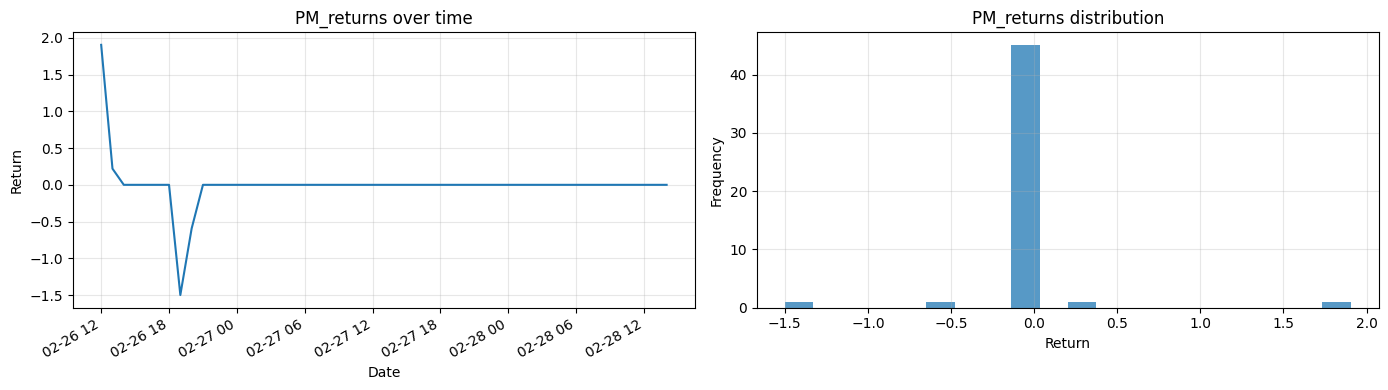

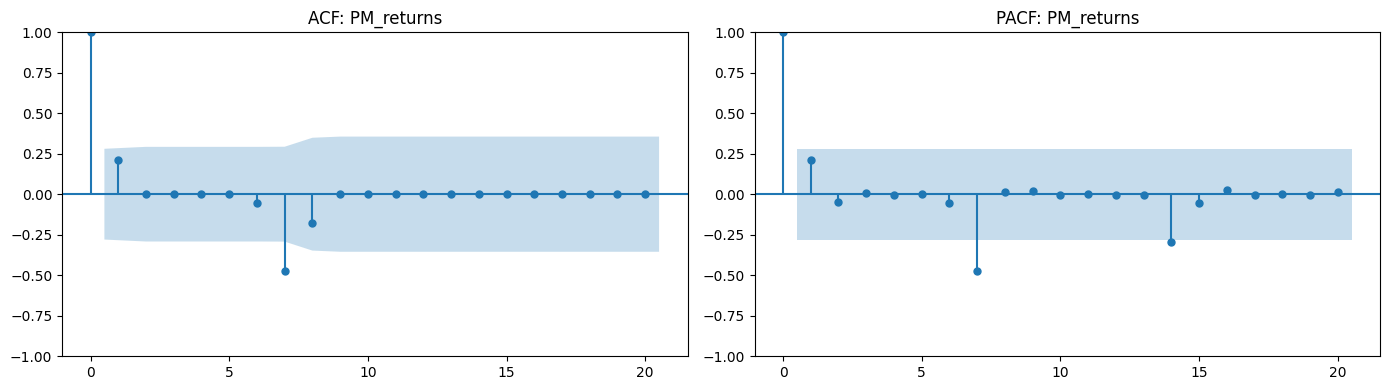

ADF statistic: -4.0764 | p-value: 0.0011
ADF conclusion (5%): Stationary
KPSS statistic: 0.0835 | p-value: 0.1000
KPSS conclusion (5%): Stationary

Series: BEL_idiosyncratic
Observations: 7


/var/folders/h9/cypcrhp14dn4gqqq118p8dyh0000gn/T/ipykernel_29896/4262617980.py:82: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(sr, regression="c", nlags="auto")


,mean,std,min,max,skew,kurtosis
BEL_idiosyncratic,-6.090366e-15,65.732071,-82.900242,122.858659,0.97159,1.605092


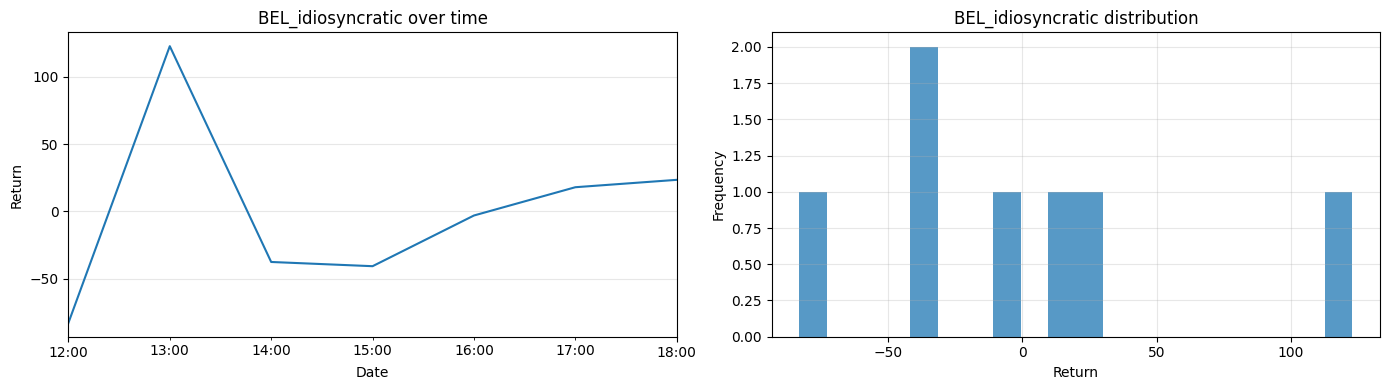

Skipping ACF/PACF and ADF/KPSS due to too few observations.


In [14]:
# ====================================================
# Time-series EDA: Prediction market returns and Belgian idiosyncratic returns
# Includes autocorrelation and stationarity checks
# ====================================================
import matplotlib.pyplot as plt

try:
    from statsmodels.tsa.stattools import adfuller, kpss
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    statsmodels_available = True
except Exception as exc:
    statsmodels_available = False
    print("statsmodels is required for ACF/PACF and ADF/KPSS tests.")
    print("Install with: pip install statsmodels")
    print("Import error:", exc)

# Build prediction-market returns from level prices (Yes contract)
pm_returns = hourly_aligned.copy().sort_values("timestamp")
pm_returns["PM_returns"] = pm_returns["price_Yes"].pct_change() * 100

series_map = {
    "PM_returns": pm_returns.set_index("timestamp")["PM_returns"],
    "BEL_idiosyncratic": hourly_aligned.set_index("timestamp").get("BEL_idiosyncratic"),
}

if series_map["BEL_idiosyncratic"] is None:
    raise ValueError("BEL_idiosyncratic not found. Run the Belgian factor model cell first.")

for name, sr in series_map.items():
    sr = sr.dropna().copy()
    if sr.empty:
        print(f"Skipping {name}: no non-NaN observations.")
        continue

    print("=" * 70)
    print(f"Series: {name}")
    print(f"Observations: {len(sr)}")

    # Descriptive stats
    desc = pd.DataFrame({
        "mean": [sr.mean()],
        "std": [sr.std()],
        "min": [sr.min()],
        "max": [sr.max()],
        "skew": [sr.skew()],
        "kurtosis": [sr.kurt()],
    }, index=[name])
    display(desc)

    # Time-series and distribution view
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sr.plot(ax=axes[0], title=f"{name} over time")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Return")
    axes[0].grid(alpha=0.3)

    axes[1].hist(sr, bins=20, alpha=0.75)
    axes[1].set_title(f"{name} distribution")
    axes[1].set_xlabel("Return")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    if statsmodels_available and len(sr) >= 8:
        # ACF / PACF
        max_lags = min(20, max(1, len(sr) // 2 - 1))
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        plot_acf(sr, lags=max_lags, ax=axes[0])
        axes[0].set_title(f"ACF: {name}")
        plot_pacf(sr, lags=max_lags, ax=axes[1], method="ywm")
        axes[1].set_title(f"PACF: {name}")
        plt.tight_layout()
        plt.show()

        # Stationarity tests: ADF (H0: unit root), KPSS (H0: stationary)
        adf_stat, adf_p, *_ = adfuller(sr, autolag="AIC")
        print(f"ADF statistic: {adf_stat:.4f} | p-value: {adf_p:.4f}")
        print("ADF conclusion (5%):", "Stationary" if adf_p < 0.05 else "Non-stationary")

        try:
            kpss_stat, kpss_p, *_ = kpss(sr, regression="c", nlags="auto")
            print(f"KPSS statistic: {kpss_stat:.4f} | p-value: {kpss_p:.4f}")
            print("KPSS conclusion (5%):", "Stationary" if kpss_p >= 0.05 else "Non-stationary")
        except Exception as kpss_exc:
            print("KPSS test failed:", kpss_exc)

        print()
    elif not statsmodels_available:
        print("Skipping ACF/PACF and ADF/KPSS because statsmodels is unavailable.")
    else:
        print("Skipping ACF/PACF and ADF/KPSS due to too few observations.")

In [65]:
# ====================================================
# Predictive benchmark on Energy case: VAR, SVAR, and VECM
# Target relationship: x_t -> y_t
# Benchmark criterion: BIC (primary), AIC (tie-break)
# ====================================================

import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen

# ----------------------------------------------------
# 0) Build modeling dataframe from whichever pair exists
# ----------------------------------------------------
ts_df_raw = None
source_used = None
x_col = None
y_col = None

# Option A: direct pair in merged_inner
if "merged_inner" in globals() and isinstance(merged_inner, pd.DataFrame):
    if {"LLA_returns", "MERV_idiosyncratic"}.issubset(merged_inner.columns):
        x_col, y_col = "LLA_returns", "MERV_idiosyncratic"
        ts_df_raw = merged_inner[[x_col, y_col]].dropna().copy()
        source_used = "merged_inner"

# Option B: direct pair in hourly_aligned
if ts_df_raw is None and "hourly_aligned" in globals() and isinstance(hourly_aligned, pd.DataFrame):
    if {"LLA_returns", "MERV_idiosyncratic"}.issubset(hourly_aligned.columns):
        x_col, y_col = "LLA_returns", "MERV_idiosyncratic"
        ts_df_raw = hourly_aligned[[x_col, y_col]].dropna().copy()
        source_used = "hourly_aligned"

# Option C: PM/BEL pair currently used in this notebook
if ts_df_raw is None and "hourly_aligned" in globals() and isinstance(hourly_aligned, pd.DataFrame):
    if {"price_Yes", "BEL_idiosyncratic"}.issubset(hourly_aligned.columns):
        tmp = hourly_aligned[["timestamp", "price_Yes", "BEL_idiosyncratic"]].copy().sort_values("timestamp")
        tmp["PM_returns"] = tmp["price_Yes"].pct_change() * 100
        x_col, y_col = "PM_returns", "BEL_idiosyncratic"
        ts_df_raw = tmp[[x_col, y_col]].dropna().copy()
        source_used = "hourly_aligned(price_Yes -> PM_returns)"

if ts_df_raw is None:
    raise ValueError(
        "Could not find a valid modeling pair. Expected one of: "
        "(LLA_returns, MERV_idiosyncratic) or (PM_returns/BEL_idiosyncratic with price_Yes available)."
    )

ts_df = ts_df_raw[[x_col, y_col]].dropna().copy()
ts_df.columns = ["x_t", "y_t"]
ts_df = ts_df.reset_index(drop=True)

if len(ts_df) < 40:
    raise ValueError(f"Not enough observations for robust model comparison: {len(ts_df)}")

print(f"Source: {source_used}")
print(f"Target relationship: {x_col} -> {y_col}")
print(f"Total observations used for VAR/SVAR/VECM comparison: {len(ts_df)}")
display(ts_df.head())

max_lag = min(10, max(2, len(ts_df) // 8))

# -----------------------------
# VAR candidates
# -----------------------------
var_candidates = []
for p in range(1, max_lag + 1):
    try:
        fit = VAR(ts_df[["x_t", "y_t"]]).fit(p)
        var_candidates.append({
            "Model": "VAR",
            "lag": int(p),
            "k_ar_diff": np.nan,
            "coint_rank": np.nan,
            "AIC": float(fit.aic),
            "BIC": float(fit.bic),
            "HQIC": float(fit.hqic),
            "fit": fit,
        })
    except Exception as exc:
        print(f"VAR lag {p} failed: {exc}")

if not var_candidates:
    raise RuntimeError("All VAR candidates failed.")

# -----------------------------
# SVAR candidates (A-model: x_t contemporaneously affects y_t)
# -----------------------------
svar_candidates = []
A_template = np.array([[1, 0], ["E", 1]], dtype=object)

for p in range(1, max_lag + 1):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            mod = SVAR(ts_df[["x_t", "y_t"]], svar_type="A", A=A_template)
            fit = mod.fit(maxlags=p, ic=None, trend="c", solver="nm", maxiter=2000, maxfun=4000)

        p_eff = int(fit.k_ar)
        if p_eff < 1:
            continue

        svar_candidates.append({
            "Model": "SVAR",
            "lag": p_eff,
            "k_ar_diff": np.nan,
            "coint_rank": np.nan,
            "AIC": float(fit.aic),
            "BIC": float(fit.bic),
            "HQIC": float(fit.hqic),
            "fit": fit,
        })
    except Exception as exc:
        print(f"SVAR lag {p} failed: {exc}")

if not svar_candidates:
    print("SVAR candidates failed; proceeding with VAR/VECM results.")

# -----------------------------
# Cointegration test and VECM candidates
# -----------------------------
vecm_candidates = []
cointegration_info_energy = {"tested": False, "rank_trace_5pct": 0, "trace_table": None}

try:
    det_order = 0
    k_ar_diff_j = min(5, max(1, len(ts_df) // 20))
    johansen_res = coint_johansen(ts_df[["x_t", "y_t"]], det_order=det_order, k_ar_diff=k_ar_diff_j)

    trace_stats = johansen_res.lr1
    crit_5pct = johansen_res.cvt[:, 1]
    rank_trace_5pct = int(np.sum(trace_stats > crit_5pct))
    n_vars = ts_df.shape[1]

    trace_table = pd.DataFrame({
        "r <= i": [f"r <= {i}" for i in range(n_vars)],
        "trace_stat": trace_stats,
        "critical_5pct": crit_5pct,
        "reject_at_5pct": trace_stats > crit_5pct,
    })
    cointegration_info_energy = {
        "tested": True,
        "rank_trace_5pct": rank_trace_5pct,
        "k_ar_diff_johansen": k_ar_diff_j,
        "trace_table": trace_table,
    }

    print("Johansen trace test (5% level):")
    display(trace_table)
    print(f"Inferred cointegration rank (trace, 5%): {rank_trace_5pct}")

    if 1 <= rank_trace_5pct < n_vars:
        vecm_rank = int(rank_trace_5pct)
        max_k_ar_diff = min(8, max(1, len(ts_df) // 10))
        for k_ar_diff in range(1, max_k_ar_diff + 1):
            try:
                fit = VECM(ts_df[["x_t", "y_t"]], coint_rank=vecm_rank, k_ar_diff=k_ar_diff, deterministic="co").fit()
                vecm_candidates.append({
                    "Model": "VECM",
                    "lag": int(k_ar_diff + 1),
                    "k_ar_diff": int(k_ar_diff),
                    "coint_rank": int(vecm_rank),
                    "AIC": float(getattr(fit, "aic", np.nan)),
                    "BIC": float(getattr(fit, "bic", np.nan)),
                    "HQIC": float(getattr(fit, "hqic", np.nan)),
                    "fit": fit,
                })
            except Exception as exc:
                print(f"VECM k_ar_diff {k_ar_diff} failed: {exc}")

        if not vecm_candidates:
            print("VECM considered but all candidates failed.")
    else:
        print("VECM not included: inferred rank is not in [1, n_vars-1].")
except Exception as exc:
    print(f"Cointegration/VECM step failed: {exc}")

# -----------------------------
# Combine and rank by BIC (primary) then AIC
# -----------------------------
all_candidates = var_candidates + svar_candidates + vecm_candidates
if not all_candidates:
    raise RuntimeError("No valid model candidates were estimated.")

model_compare_energy_pred = pd.DataFrame([{k: v for k, v in c.items() if k != "fit"} for c in all_candidates])
model_compare_energy_pred = model_compare_energy_pred.sort_values(["BIC", "AIC"], na_position="last").reset_index(drop=True)

print("Predictive model comparison (lower is better):")
display(model_compare_energy_pred)

best_var_pred = min(var_candidates, key=lambda x: x["BIC"]) if var_candidates else None
best_svar_pred = min(svar_candidates, key=lambda x: x["BIC"]) if svar_candidates else None
best_vecm_pred = None
if vecm_candidates:
    finite_vecm = [c for c in vecm_candidates if np.isfinite(c["BIC"]) and np.isfinite(c["AIC"])]
    best_vecm_pred = min(finite_vecm, key=lambda x: x["BIC"]) if finite_vecm else None

selectable = [c for c in all_candidates if np.isfinite(c["BIC"]) and np.isfinite(c["AIC"])]
if not selectable:
    raise RuntimeError("No candidates with finite AIC/BIC available for model selection.")
best_overall = min(selectable, key=lambda x: (x["BIC"], x["AIC"]))

if best_var_pred is not None:
    print(f"Best VAR by BIC: lag={best_var_pred['lag']}, BIC={best_var_pred['BIC']:.6f}, AIC={best_var_pred['AIC']:.6f}")
if best_svar_pred is not None:
    print(f"Best SVAR by BIC: lag={best_svar_pred['lag']}, BIC={best_svar_pred['BIC']:.6f}, AIC={best_svar_pred['AIC']:.6f}")
if best_vecm_pred is not None:
    print(
        f"Best VECM by BIC: k_ar_diff={best_vecm_pred['k_ar_diff']}, coint_rank={best_vecm_pred['coint_rank']}, "
        f"BIC={best_vecm_pred['BIC']:.6f}, AIC={best_vecm_pred['AIC']:.6f}"
    )
print(
    f"Selected predictive model: {best_overall['Model']} "
    f"(lag={best_overall['lag']}, k_ar_diff={best_overall['k_ar_diff']})"
)

best_models_energy_pred = {
    "VAR": best_var_pred,
    "SVAR": best_svar_pred,
    "VECM": best_vecm_pred,
    "selected_model": best_overall["Model"],
    "selected_lag": best_overall["lag"],
    "selected_k_ar_diff": best_overall["k_ar_diff"],
    "model_compare_energy_pred": model_compare_energy_pred,
    "cointegration_info": cointegration_info_energy,
    "ts_df": ts_df,
    "x_col": x_col,
    "y_col": y_col,
}

# Compatibility aliases for downstream cells
best_models = best_models_energy_pred
model_compare = model_compare_energy_pred

Source: hourly_aligned(price_Yes -> PM_returns)
Target relationship: PM_returns -> BEL_idiosyncratic
Total observations used for VAR/SVAR/VECM comparison: 46


,x_t,y_t
0,0.21978,444.667765
1,0.00000,288.307662
2,0.00000,259.854639
3,0.00000,250.057391
4,0.00000,233.532472


Johansen trace test (5% level):


,r <= i,trace_stat,critical_5pct,reject_at_5pct
0,r <= 0,27.129725,15.4943,True
1,r <= 1,11.481403,3.8415,True


Inferred cointegration rank (trace, 5%): 2
VECM not included: inferred rank is not in [1, n_vars-1].
Predictive model comparison (lower is better):


,Model,lag,k_ar_diff,coint_rank,AIC,BIC,HQIC
0,VAR,1,NaN,NaN,6.641089,6.881978,6.730890
1,SVAR,1,NaN,NaN,6.641089,6.881978,6.730890
2,VAR,2,NaN,NaN,6.785733,7.191231,6.936111
3,SVAR,2,NaN,NaN,6.785733,7.191231,6.936111
4,VAR,3,NaN,NaN,6.784521,7.357935,6.995978
5,SVAR,3,NaN,NaN,6.784521,7.357935,6.995978
6,VAR,4,NaN,NaN,6.998131,7.742846,7.271098
7,SVAR,4,NaN,NaN,6.998131,7.742846,7.271098
8,VAR,5,NaN,NaN,7.227762,8.147240,7.562585
9,SVAR,5,NaN,NaN,7.227762,8.147240,7.562585


Best VAR by BIC: lag=1, BIC=6.881978, AIC=6.641089
Best SVAR by BIC: lag=1, BIC=6.881978, AIC=6.641089
Selected predictive model: VAR (lag=1, k_ar_diff=nan)


Initial dataset size: 635 rows
After filtering to PM-available period: 50 rows
Simulation anchor timestamp (T-5): 2026-02-28 10:00:00+00:00
PM level at T-5 (used as probability weight): 0.2350
Electricity level at T-5: -0.020000
Forecast horizon: 5 observations

Stage-1 binomial calibration:
down node PM level: 0.2344
up node PM level:   0.2356
Selected predictive engine: VAR
Engine metadata:


,selected_model,source_rows,type,lag
0,VAR,42,VAR,1



Binomial path-level summary:


,branch,stage1,stage1_prob_node,probability,terminal_resolution,base_prob_t_minus_5,step1_prob_level,horizon_steps,predictive_engine,terminal_abnormal_return,max_drawdown,terminal_electricity_level
0,down->resolve_0,down,0.234421,0.382789,0,0.235,0.234421,5,VAR,207.566007,0.0,-4.171320
1,down->resolve_1,down,0.234421,0.117211,1,0.235,0.234421,5,VAR,207.566007,0.0,-4.171320
2,up->resolve_0,up,0.235579,0.382211,0,0.235,0.235579,5,VAR,200.988206,0.0,-4.039764
3,up->resolve_1,up,0.235579,0.117789,1,0.235,0.235579,5,VAR,200.988206,0.0,-4.039764


Terminal-node summary (only two final nodes):


,terminal_resolution,terminal_label,total_probability,expected_terminal_abnormal_return,weighted_max_drawdown
0,0,Resolves to 0,0.765,204.279594,0.0
1,1,Resolves to 1,0.235,204.269010,0.0


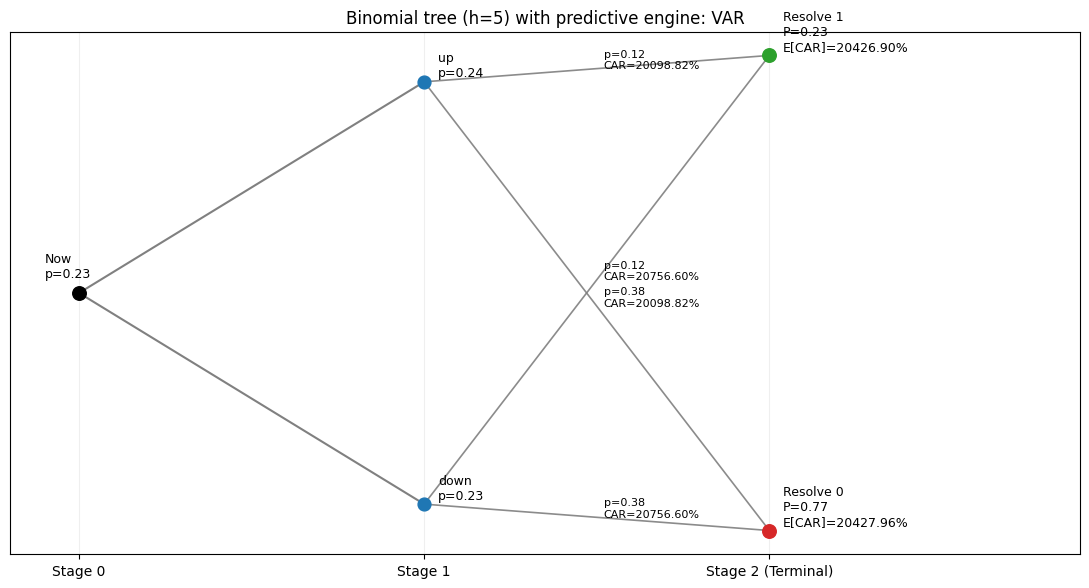

Distribution summary (path-level):


,metric,value
0,Expected terminal abnormal return,204.277107
1,5% quantile (VaR-like),200.988206
2,Expected shortfall 95%,200.988206


Total probability across all branches: 1.000000


In [66]:
# ====================================================
# Binomial tree simulation from T-5 with binary terminal resolution
# Uses selected traditional model (VAR/SVAR/VECM) from benchmark
# ====================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from statsmodels.tsa.vector_ar.vecm import VECM

if "best_models_energy_pred" not in globals() or not isinstance(best_models_energy_pred, dict):
    raise ValueError("best_models_energy_pred is required. Run the predictive benchmark cell first.")

# ----------------------------------------------------
# 0) Build simulation dataset with robust column detection
# ----------------------------------------------------
pm_level_col = None
elec_level_col = None

if "hourly_aligned" not in globals() or not isinstance(hourly_aligned, pd.DataFrame):
    raise ValueError("hourly_aligned is required for this simulation.")

for cand in ["price_Yes", "LLA (La Libertad Avanza)"]:
    if cand in hourly_aligned.columns:
        pm_level_col = cand
        break

for cand in ["Country Hourly - Belgium", "^MERV"]:
    if cand in hourly_aligned.columns:
        elec_level_col = cand
        break

if pm_level_col is None:
    raise ValueError("Could not find a PM level column (expected price_Yes or LLA-like level column).")
if elec_level_col is None:
    raise ValueError("Could not find an electricity/market level column (expected Country Hourly - Belgium or ^MERV).")

x_ret_col = str(best_models_energy_pred.get("x_col", "PM_returns"))
y_idio_col = str(best_models_energy_pred.get("y_col", "BEL_idiosyncratic"))

sim_df = hourly_aligned.copy().sort_values("timestamp").reset_index(drop=True)
if x_ret_col not in sim_df.columns:
    sim_df[x_ret_col] = sim_df[pm_level_col].pct_change() * 100

need_cols = ["timestamp", pm_level_col, x_ret_col, y_idio_col, elec_level_col]
missing = [c for c in need_cols if c not in sim_df.columns]
if missing:
    raise ValueError(f"Missing required columns for simulation: {missing}")

sim_df = sim_df[need_cols].copy()
print(f"Initial dataset size: {len(sim_df)} rows")
sim_df = sim_df[sim_df[pm_level_col].notna()].copy()
print(f"After filtering to PM-available period: {len(sim_df)} rows")

if len(sim_df) < 15:
    horizon = max(2, len(sim_df) - 8)
    print(f"Dataset has only {len(sim_df)} observations. Adapting horizon to {horizon}.")
elif len(sim_df) < 30:
    horizon = min(5, max(3, len(sim_df) - 10))
    print(f"Dataset has {len(sim_df)} observations. Using adapted horizon of {horizon}.")
else:
    horizon = 5

if len(sim_df) <= horizon + 2:
    raise ValueError(f"Even after adaptation, not enough observations. Need > {horizon + 2}, got {len(sim_df)}")

t0_pos = len(sim_df) - (horizon + 1)
t0_row = sim_df.iloc[t0_pos]
p_t0 = float(np.clip(t0_row[pm_level_col], 0.0, 1.0))
elec_t0 = float(t0_row[elec_level_col])
t0_ts = pd.Timestamp(t0_row["timestamp"])

print(f"Simulation anchor timestamp (T-5): {t0_ts}")
print(f"PM level at T-5 (used as probability weight): {p_t0:.4f}")
print(f"Electricity level at T-5: {elec_t0:.6f}")
print(f"Forecast horizon: {horizon} observations")

train_sim = sim_df.iloc[: t0_pos + 1][[x_ret_col, y_idio_col]].dropna().copy()
if len(train_sim) < 20:
    raise ValueError(f"Training sample too short up to T-5: {len(train_sim)}")

# ----------------------------------------------------
# Stage 1 calibration (binomial)
# ----------------------------------------------------
pm_hist = sim_df.iloc[: t0_pos + 1][pm_level_col].astype(float).clip(0.0, 1.0)
delta_hist = pm_hist.diff().dropna()
if delta_hist.empty:
    raise RuntimeError("Insufficient PM level history to calibrate Stage-1 binomial moves.")

q_down = float(delta_hist.quantile(0.25))
q_up = float(delta_hist.quantile(0.75))

if abs(q_up - q_down) < 1e-10:
    std_val = float(delta_hist.std(ddof=0)) if float(delta_hist.std(ddof=0)) > 0 else 1e-3
    eps = max(1e-4, std_val)
    q_down, q_up = -eps, eps

p_stage1_down = float(np.clip(p_t0 + q_down, 0.0, 1.0))
p_stage1_up = float(np.clip(p_t0 + q_up, 0.0, 1.0))

if abs(p_stage1_up - p_stage1_down) < 1e-10:
    med_abs = float(delta_hist.abs().median()) if not delta_hist.empty else 1e-3
    bump = min(0.05, max(1e-3, med_abs))
    p_stage1_down = float(np.clip(p_t0 - bump, 0.0, 1.0))
    p_stage1_up = float(np.clip(p_t0 + bump, 0.0, 1.0))

stage1_nodes = {"down": p_stage1_down, "up": p_stage1_up}
stage1_prob = {"down": 0.5, "up": 0.5}

print("\nStage-1 binomial calibration:")
print(f"down node PM level: {p_stage1_down:.4f}")
print(f"up node PM level:   {p_stage1_up:.4f}")

# ----------------------------------------------------
# Fit selected predictive engine on train_sim
# ----------------------------------------------------
selected_predictive_model = str(best_models_energy_pred.get("selected_model", "VAR"))
print(f"Selected predictive engine: {selected_predictive_model}")

ts_engine = train_sim[[x_ret_col, y_idio_col]].dropna().copy().reset_index(drop=True)
if len(ts_engine) < 20:
    raise ValueError("Not enough rows to fit selected predictive engine.")

engine_meta = {"selected_model": selected_predictive_model, "source_rows": len(ts_engine)}

if selected_predictive_model == "VAR":
    lag = int(best_models_energy_pred.get("VAR", {}).get("lag", 1)) if best_models_energy_pred.get("VAR") is not None else 1
    var_engine_fit = VAR(ts_engine[[x_ret_col, y_idio_col]]).fit(lag)
    coefs = np.array(var_engine_fit.coefs, dtype=float)
    intercept = np.array(var_engine_fit.intercept, dtype=float)
    k_ar = int(coefs.shape[0])

    def simulate_y_path_from_x_path(x_future):
        x_future = np.asarray(x_future, dtype=float)
        x_hist = ts_engine[x_ret_col].astype(float).tolist()
        y_hist = ts_engine[y_idio_col].astype(float).tolist()
        if len(x_hist) < k_ar or len(y_hist) < k_ar:
            raise RuntimeError(f"Not enough history for VAR lag order {k_ar}.")
        preds = []
        for x_next in x_future:
            y_next = float(intercept[1])
            for lag_i in range(1, k_ar + 1):
                A = coefs[lag_i - 1]
                y_next += float(A[1, 0]) * float(x_hist[-lag_i])
                y_next += float(A[1, 1]) * float(y_hist[-lag_i])
            preds.append(y_next)
            x_hist.append(float(x_next))
            y_hist.append(y_next)
        return np.asarray(preds, dtype=float)

    engine_meta.update({"type": "VAR", "lag": lag})

elif selected_predictive_model == "SVAR":
    lag = int(best_models_energy_pred.get("SVAR", {}).get("lag", 1)) if best_models_energy_pred.get("SVAR") is not None else 1
    A_template = np.array([[1, 0], ["E", 1]], dtype=object)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        svar_mod_engine = SVAR(ts_engine[[x_ret_col, y_idio_col]], svar_type="A", A=A_template)
        svar_engine_fit = svar_mod_engine.fit(maxlags=lag, ic=None, trend="c", solver="nm", maxiter=2000, maxfun=4000)

    coefs = np.array(svar_engine_fit.coefs, dtype=float)
    intercept = np.array(svar_engine_fit.intercept, dtype=float)
    k_ar = int(coefs.shape[0])

    def simulate_y_path_from_x_path(x_future):
        x_future = np.asarray(x_future, dtype=float)
        x_hist = ts_engine[x_ret_col].astype(float).tolist()
        y_hist = ts_engine[y_idio_col].astype(float).tolist()
        if len(x_hist) < k_ar or len(y_hist) < k_ar:
            raise RuntimeError(f"Not enough history for SVAR lag order {k_ar}.")
        preds = []
        for x_next in x_future:
            y_next = float(intercept[1])
            for lag_i in range(1, k_ar + 1):
                A = coefs[lag_i - 1]
                y_next += float(A[1, 0]) * float(x_hist[-lag_i])
                y_next += float(A[1, 1]) * float(y_hist[-lag_i])
            preds.append(y_next)
            x_hist.append(float(x_next))
            y_hist.append(y_next)
        return np.asarray(preds, dtype=float)

    engine_meta.update({"type": "SVAR", "lag": lag})

elif selected_predictive_model == "VECM":
    if best_models_energy_pred.get("VECM") is None:
        raise RuntimeError("Selected model is VECM but no valid VECM specification is stored.")
    vecm_spec = best_models_energy_pred["VECM"]
    coint_rank = int(vecm_spec["coint_rank"])
    k_ar_diff = int(vecm_spec["k_ar_diff"])
    vecm_engine_fit = VECM(ts_engine[[x_ret_col, y_idio_col]], coint_rank=coint_rank, k_ar_diff=k_ar_diff, deterministic="co").fit()
    coefs = np.array(vecm_engine_fit.var_rep, dtype=float)
    det_coef = getattr(vecm_engine_fit, "det_coef", None)
    if det_coef is not None and np.size(det_coef) > 0:
        intercept = np.array(det_coef, dtype=float)[:, 0]
    else:
        intercept = np.zeros(ts_engine.shape[1], dtype=float)
    k_ar = int(coefs.shape[0])

    def simulate_y_path_from_x_path(x_future):
        x_future = np.asarray(x_future, dtype=float)
        x_hist = ts_engine[x_ret_col].astype(float).tolist()
        y_hist = ts_engine[y_idio_col].astype(float).tolist()
        if len(x_hist) < k_ar or len(y_hist) < k_ar:
            raise RuntimeError(f"Not enough history for VECM lag order {k_ar}.")
        preds = []
        for x_next in x_future:
            y_next = float(intercept[1])
            for lag_i in range(1, k_ar + 1):
                A = coefs[lag_i - 1]
                y_next += float(A[1, 0]) * float(x_hist[-lag_i])
                y_next += float(A[1, 1]) * float(y_hist[-lag_i])
            preds.append(y_next)
            x_hist.append(float(x_next))
            y_hist.append(y_next)
        return np.asarray(preds, dtype=float)

    engine_meta.update({"type": "VECM", "k_ar_diff": k_ar_diff, "coint_rank": coint_rank, "lag": k_ar})

else:
    raise ValueError(f"Unsupported selected_predictive_model: {selected_predictive_model}")

predictive_sim_meta = engine_meta
print("Engine metadata:")
display(pd.DataFrame([predictive_sim_meta]))

# ----------------------------------------------------
# Build binomial branches
# ----------------------------------------------------
def safe_return(next_level, prev_level):
    if prev_level <= 1e-12:
        return 0.0 if next_level <= 1e-12 else 1e6
    return float(next_level / prev_level - 1.0)

scenario_rows = []
path_outputs = {}

for s1_name, p1 in stage1_nodes.items():
    p1_prob = float(stage1_prob[s1_name])
    ret_step1 = safe_return(p1, p_t0) * 100.0

    for terminal in [1.0, 0.0]:
        ret_terminal = safe_return(terminal, p1) * 100.0
        x_path = np.zeros(horizon, dtype=float)
        x_path[0] = ret_step1
        x_path[-1] = ret_terminal

        idio_path = simulate_y_path_from_x_path(x_path)
        elec_path = elec_t0 * np.cumprod(1.0 + idio_path / 100.0)

        cond_prob = float(np.clip(p1, 0.0, 1.0)) if terminal == 1.0 else float(1.0 - np.clip(p1, 0.0, 1.0))
        joint_prob = p1_prob * cond_prob

        node_name = f"{s1_name}->resolve_{int(terminal)}"
        path_outputs[node_name] = {
            "elec_path": elec_path,
            "idio_path": idio_path,
            "x_path": x_path,
            "joint_prob": joint_prob,
            "terminal": int(terminal),
        }

        scenario_rows.append({
            "branch": node_name,
            "stage1": s1_name,
            "stage1_prob_node": p1,
            "probability": joint_prob,
            "terminal_resolution": int(terminal),
            "base_prob_t_minus_5": p_t0,
            "step1_prob_level": p1,
            "horizon_steps": horizon,
            "predictive_engine": predictive_sim_meta.get("selected_model", "unknown"),
            "terminal_abnormal_return": float(elec_path[-1] / elec_t0 - 1.0),
            "max_drawdown": float((elec_path / np.maximum.accumulate(elec_path) - 1.0).min()),
            "terminal_electricity_level": float(elec_path[-1]),
        })

scenario_summary = pd.DataFrame(scenario_rows).sort_values(["stage1", "terminal_resolution"]).reset_index(drop=True)
print("\nBinomial path-level summary:")
display(scenario_summary)

terminal_summary = (
    scenario_summary
    .groupby("terminal_resolution", as_index=False)
    .apply(lambda g: pd.Series({
        "total_probability": g["probability"].sum(),
        "expected_terminal_abnormal_return": np.average(g["terminal_abnormal_return"], weights=g["probability"]) if g["probability"].sum() > 0 else np.nan,
        "weighted_max_drawdown": np.average(g["max_drawdown"], weights=g["probability"]) if g["probability"].sum() > 0 else np.nan,
    }))
    .reset_index(drop=True)
)
terminal_summary["terminal_label"] = terminal_summary["terminal_resolution"].map({1: "Resolves to 1", 0: "Resolves to 0"})
terminal_summary = terminal_summary[[
    "terminal_resolution",
    "terminal_label",
    "total_probability",
    "expected_terminal_abnormal_return",
    "weighted_max_drawdown",
]]

print("Terminal-node summary (only two final nodes):")
display(terminal_summary)

fig, ax = plt.subplots(figsize=(11, 6))
root = (0.0, 0.0)
stage1_xy = {"down": (1.0, -0.8), "up": (1.0, 0.8)}
terminal_xy = {0: (2.0, -0.9), 1: (2.0, 0.9)}

ax.scatter([root[0]], [root[1]], s=95, c="black", zorder=5)
ax.text(root[0] - 0.10, root[1] + 0.06, f"Now\np={p_t0:.2f}", fontsize=9)

for s1_name, (x1, y1) in stage1_xy.items():
    p1 = stage1_nodes[s1_name]
    ax.plot([root[0], x1], [root[1], y1], color="gray", linewidth=1.5)
    ax.scatter([x1], [y1], s=85, c="tab:blue", zorder=5)
    ax.text(x1 + 0.04, y1 + 0.02, f"{s1_name}\np={p1:.2f}", fontsize=9)

for s1_name, (x1, y1) in stage1_xy.items():
    for terminal, (x2, y2) in terminal_xy.items():
        path_key = f"{s1_name}->resolve_{terminal}"
        p_joint = path_outputs[path_key]["joint_prob"]
        car = float(path_outputs[path_key]["elec_path"][-1] / elec_t0 - 1.0)
        ax.plot([x1, x2], [y1, y2], color="tab:gray", linewidth=1.2, alpha=0.9)
        ax.text((x1 + x2) / 2 + 0.02, (y1 + y2) / 2, f"p={p_joint:.2f}\nCAR={car:.2%}", fontsize=8)

for terminal, (x2, y2) in terminal_xy.items():
    p_total = float(terminal_summary.loc[terminal_summary["terminal_resolution"] == terminal, "total_probability"].sum())
    exp_ret = float(terminal_summary.loc[terminal_summary["terminal_resolution"] == terminal, "expected_terminal_abnormal_return"].iloc[0])
    color = "tab:green" if terminal == 1 else "tab:red"
    ax.scatter([x2], [y2], s=95, c=color, zorder=6)
    ax.text(x2 + 0.04, y2 + 0.02, f"Resolve {terminal}\nP={p_total:.2f}\nE[CAR]={exp_ret:.2%}", fontsize=9)

ax.set_title(f"Binomial tree (h={horizon}) with predictive engine: {selected_predictive_model}")
ax.set_xlim(-0.2, 2.9)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Stage 0", "Stage 1", "Stage 2 (Terminal)"])
ax.set_yticks([])
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

w = scenario_summary["probability"].to_numpy()
r = scenario_summary["terminal_abnormal_return"].to_numpy()
expected_terminal = float(np.sum(w * r))
var95 = float(np.quantile(r, 0.05))
es95 = float(r[r <= var95].mean()) if np.any(r <= var95) else var95

scenario_stats = pd.DataFrame({
    "metric": ["Expected terminal abnormal return", "5% quantile (VaR-like)", "Expected shortfall 95%"],
    "value": [expected_terminal, var95, es95],
})
print("Distribution summary (path-level):")
display(scenario_stats)

prob_check = float(scenario_summary["probability"].sum())
print(f"Total probability across all branches: {prob_check:.6f}")

# Keep outputs in memory for downstream use
binomial_scenario_summary = scenario_summary
binomial_terminal_summary = terminal_summary
binomial_stats = scenario_stats

In [50]:
# ====================================================
# Proposal-aligned hedge sizing with positive-branch handling
# Consumes scenario_summary from the PM->electricity binomial simulation
# ====================================================

portfolio_value = 1_000_000
risk_budget_fraction = 0.015
execution_haircut = 0.70
hedge_efficiency = 0.60  # conservative payoff efficiency after costs/slippage

# Exposure convention:
# - "short_price": rising electricity prices are adverse (typical buyer/procurement view)
# - "long_price": falling electricity prices are adverse (producer/merchant view)
exposure_to_price = "short_price"

if "scenario_summary" not in globals() or scenario_summary.empty:
    raise ValueError("scenario_summary is missing or empty. Run the binomial simulation cell first.")

hedge_table = scenario_summary.copy()

# Ensure terminal electricity level is available for each branch
if "terminal_electricity_level" not in hedge_table.columns:
    if "path_outputs" in globals() and isinstance(path_outputs, dict):
        hedge_table["terminal_electricity_level"] = hedge_table["branch"].map(
            lambda b: float(path_outputs[b]["elec_path"][-1]) if b in path_outputs else np.nan
        )
    else:
        hedge_table["terminal_electricity_level"] = np.nan

# Keep compatibility with prior tree formats
if "year_shift" not in hedge_table.columns:
    hedge_table["year_shift"] = np.nan
if "horizon_days" not in hedge_table.columns and "horizon_steps" in hedge_table.columns:
    hedge_table["horizon_days"] = hedge_table["horizon_steps"]

ret = hedge_table["terminal_abnormal_return"].to_numpy(dtype=float)
w = hedge_table["probability"].to_numpy(dtype=float)

if exposure_to_price == "short_price":
    # Adverse outcome is electricity price increase
    loss = np.maximum(ret, 0.0)
elif exposure_to_price == "long_price":
    # Adverse outcome is electricity price decline
    loss = np.maximum(-ret, 0.0)
else:
    raise ValueError("exposure_to_price must be 'short_price' or 'long_price'.")

weighted_loss = float(np.sum(w * loss))

# Hedge only the loss in excess of the risk budget
if weighted_loss <= risk_budget_fraction:
    target_coverage = 0.0
else:
    target_coverage = (weighted_loss - risk_budget_fraction) / weighted_loss

raw_hedge_notional_pct = target_coverage / hedge_efficiency if hedge_efficiency > 0 else 0.0
hedge_notional_pct = float(np.clip(raw_hedge_notional_pct * execution_haircut, 0.0, 0.80))
hedge_notional_usd = hedge_notional_pct * portfolio_value

def hedge_instrument_mix(terminal_ret: float, side: str) -> str:
    if side == "short_price":
        # Buyer: higher prices hurt, so hedge upside in power prices
        if terminal_ret <= 0:
            return "No upside power-price hedge required; keep optional flexibility."
        if terminal_ret < 0.02:
            return "Light hedge: staged baseload futures/swaps for near delivery window."
        if terminal_ret < 0.05:
            return "Medium hedge: layered fixed-price forwards + upside cap structure."
        return "Strong hedge: high hedge ratio via strips/swaps plus call-option caps."

    # Seller/producer: lower prices hurt, so hedge downside in power prices
    if terminal_ret >= 0:
        return "No downside power-price hedge required; keep upside participation."
    if terminal_ret > -0.02:
        return "Light hedge: modest floor via put spread or fixed-price tranche."
    if terminal_ret > -0.05:
        return "Medium hedge: protective floor/collar with staged execution."
    return "Strong hedge: high floor coverage + partial de-risking of merchant exposure."

hedge_table["recommended_hedge_structure"] = hedge_table["terminal_abnormal_return"].apply(
    lambda x: hedge_instrument_mix(float(x), exposure_to_price)
)
hedge_table["suggested_hedge_notional_pct_of_exposure"] = hedge_notional_pct
hedge_table["suggested_hedge_notional_usd"] = hedge_notional_usd

display_cols = [
    "branch",
    "stage1",
    "probability",
    "year_shift",
    "horizon_days",
    "terminal_resolution",
    "terminal_electricity_level",
    "terminal_abnormal_return",
    "max_drawdown",
    "recommended_hedge_structure",
    "suggested_hedge_notional_pct_of_exposure",
    "suggested_hedge_notional_usd",
]

print(f"Exposure mode: {exposure_to_price}")
display(hedge_table[display_cols])

hedge_policy = pd.DataFrame(
    {
        "parameter": [
            "portfolio_value",
            "exposure_to_price",
            "risk_budget_fraction",
            "execution_haircut",
            "hedge_efficiency",
            "weighted_loss",
            "target_coverage",
            "final_hedge_notional_pct",
            "final_hedge_notional_usd",
        ],
        "value": [
            portfolio_value,
            exposure_to_price,
            risk_budget_fraction,
            execution_haircut,
            hedge_efficiency,
            weighted_loss,
            target_coverage,
            hedge_notional_pct,
            hedge_notional_usd,
        ],
    }
)

display(hedge_policy)
print("Research use only: scenario-based hedge sizing for thesis simulation, not investment advice.")

# Persist outputs for downstream cells
hedge_recommendation_table = hedge_table
hedge_policy_table = hedge_policy


Exposure mode: short_price


,branch,stage1,probability,year_shift,horizon_days,terminal_resolution,terminal_electricity_level,terminal_abnormal_return,max_drawdown,recommended_hedge_structure,suggested_hedge_notional_pct_of_exposure,suggested_hedge_notional_usd
0,down->resolve_0,down,0.380697,NaN,5,0,35.835434,0.066531,-0.139828,Strong hedge: high hedge ratio via strips/swap...,0.8,800000.0
1,down->resolve_1,down,0.119303,NaN,5,1,35.835434,0.066531,-0.139828,Strong hedge: high hedge ratio via strips/swap...,0.8,800000.0
2,up->resolve_0,up,0.379303,NaN,5,0,46.518632,0.384483,-0.081301,Strong hedge: high hedge ratio via strips/swap...,0.8,800000.0
3,up->resolve_1,up,0.120697,NaN,5,1,46.518632,0.384483,-0.081301,Strong hedge: high hedge ratio via strips/swap...,0.8,800000.0


,parameter,value
0,portfolio_value,1000000
1,exposure_to_price,short_price
2,risk_budget_fraction,0.015
3,execution_haircut,0.7
4,hedge_efficiency,0.6
5,weighted_loss,0.225507
6,target_coverage,0.933483
7,final_hedge_notional_pct,0.8
8,final_hedge_notional_usd,800000.0


Research use only: scenario-based hedge sizing for thesis simulation, not investment advice.


In [ ]:
# ====================================================
# Monte Carlo: electricity idiosyncratic returns under terminal PM resolution {0, 1}
# Uses selected traditional predictive engine and residual bootstrap noise
# ====================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from statsmodels.tsa.vector_ar.vecm import VECM

n_sims = 5000
seed = 42
rng = np.random.default_rng(seed)

required_vars = [
    "sim_df",
    "train_sim",
    "p_t0",
    "elec_t0",
    "pm_level_col",
    "y_idio_col",
    "x_ret_col",
    "horizon",
    "best_models_energy_pred",
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise ValueError(
        f"Missing required variables from binomial simulation: {missing_vars}. "
        "Run the predictive benchmark and binomial simulation cells first."
    )

sim_df_mc = sim_df[[pm_level_col, x_ret_col, y_idio_col]].copy().dropna()

min_required = 10
if len(sim_df_mc) < min_required:
    adjusted_horizon = int(max(2, len(sim_df_mc) - 8))
    print(
        f"Dataset has {len(sim_df_mc)} observations. "
        f"Adapting horizon from {horizon} to {adjusted_horizon}."
    )
    horizon = adjusted_horizon
else:
    horizon = min(horizon, len(sim_df_mc) - 8)

if len(sim_df_mc) <= horizon + 8:
    raise ValueError(
        f"Insufficient aligned observations for Monte Carlo after adjustment. "
        f"Need > {horizon + 8}, got {len(sim_df_mc)}"
    )

t0_pos_mc = len(sim_df_mc) - (horizon + 1)
train_mc = sim_df_mc.iloc[: t0_pos_mc + 1][[x_ret_col, y_idio_col]].dropna().copy()
if len(train_mc) < 20:
    raise ValueError(f"Training sample too short for Monte Carlo engine: {len(train_mc)}")

print(f"Anchor PM probability at T-{horizon+1}: {p_t0:.4f}")
print(f"Anchor electricity level at T-{horizon+1}: {elec_t0:.6f}")
print(f"Training rows: {len(train_mc)}")
print(f"Monte Carlo simulations: {n_sims} with horizon={horizon}")

selected_predictive_model = str(best_models_energy_pred.get("selected_model", "VAR"))
print(f"Selected predictive engine for Monte Carlo: {selected_predictive_model}")

ts_engine_mc = train_mc[[x_ret_col, y_idio_col]].dropna().copy().reset_index(drop=True)

if selected_predictive_model == "VAR":
    lag = int(best_models_energy_pred.get("VAR", {}).get("lag", 1)) if best_models_energy_pred.get("VAR") is not None else 1
    var_engine_fit = VAR(ts_engine_mc[[x_ret_col, y_idio_col]]).fit(lag)
    coefs = np.array(var_engine_fit.coefs, dtype=float)
    intercept = np.array(var_engine_fit.intercept, dtype=float)
    resid_pool = var_engine_fit.resid.iloc[:, 1].dropna().to_numpy(dtype=float)
    k_ar = int(coefs.shape[0])

elif selected_predictive_model == "SVAR":
    lag = int(best_models_energy_pred.get("SVAR", {}).get("lag", 1)) if best_models_energy_pred.get("SVAR") is not None else 1
    A_template = np.array([[1, 0], ["E", 1]], dtype=object)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        svar_mod_mc = SVAR(ts_engine_mc[[x_ret_col, y_idio_col]], svar_type="A", A=A_template)
        svar_engine_fit = svar_mod_mc.fit(maxlags=lag, ic=None, trend="c", solver="nm", maxiter=2000, maxfun=4000)
    coefs = np.array(svar_engine_fit.coefs, dtype=float)
    intercept = np.array(svar_engine_fit.intercept, dtype=float)
    resid_pool = pd.Series(np.array(svar_engine_fit.resid)[:, 1]).dropna().to_numpy(dtype=float)
    k_ar = int(coefs.shape[0])

elif selected_predictive_model == "VECM":
    if best_models_energy_pred.get("VECM") is None:
        raise RuntimeError("Selected model is VECM but no valid VECM specification is stored.")
    vecm_spec = best_models_energy_pred["VECM"]
    coint_rank = int(vecm_spec["coint_rank"])
    k_ar_diff = int(vecm_spec["k_ar_diff"])
    vecm_engine_fit = VECM(ts_engine_mc[[x_ret_col, y_idio_col]], coint_rank=coint_rank, k_ar_diff=k_ar_diff, deterministic="co").fit()
    coefs = np.array(vecm_engine_fit.var_rep, dtype=float)
    det_coef = getattr(vecm_engine_fit, "det_coef", None)
    if det_coef is not None and np.size(det_coef) > 0:
        intercept = np.array(det_coef, dtype=float)[:, 0]
    else:
        intercept = np.zeros(ts_engine_mc.shape[1], dtype=float)
    resid_raw = getattr(vecm_engine_fit, "resid", None)
    if resid_raw is None:
        resid_pool = np.array([0.0], dtype=float)
    else:
        resid_pool = pd.Series(np.array(resid_raw)[:, 1]).dropna().to_numpy(dtype=float)
    k_ar = int(coefs.shape[0])

else:
    raise ValueError(f"Unsupported selected_predictive_model: {selected_predictive_model}")

if resid_pool.size == 0:
    resid_pool = np.array([0.0], dtype=float)

resid_std = float(np.std(resid_pool, ddof=0)) if resid_pool.size > 1 else 0.0
if resid_std < 1e-9:
    y_std = float(ts_engine_mc[y_idio_col].std(ddof=0))
    fallback_std = max(1e-6, 0.05 * y_std)
    resid_pool = rng.normal(0.0, fallback_std, size=max(200, len(ts_engine_mc)))
    resid_std = float(np.std(resid_pool, ddof=0))

print(f"Residual noise pool size: {len(resid_pool)} | residual std: {resid_std:.6f}")

pm_hist_levels = sim_df_mc.iloc[: t0_pos_mc + 1][pm_level_col].astype(float).clip(0.0, 1.0)
delta_hist = pm_hist_levels.diff().dropna().to_numpy()
if len(delta_hist) == 0:
    raise RuntimeError("Insufficient PM level history to simulate paths.")

terminal_is_one = rng.random(n_sims) < p_t0
terminal_vals = np.where(terminal_is_one, 1.0, 0.0)
n_terminal_1 = int(terminal_is_one.sum())
n_terminal_0 = int(n_sims - n_terminal_1)

print(
    f"Simulated terminal counts from p={p_t0:.4f}: "
    f"resolve=1 -> {n_terminal_1}, resolve=0 -> {n_terminal_0}"
)

levels = np.empty((n_sims, horizon + 1), dtype=float)
levels[:, 0] = p_t0
for t in range(1, horizon):
    step = rng.choice(delta_hist, size=n_sims, replace=True)
    levels[:, t] = np.clip(levels[:, t - 1] + step, 0.0, 1.0)
levels[:, -1] = terminal_vals

prev = levels[:, :-1]
curr = levels[:, 1:]
pm_ret_paths = np.where(
    prev <= 1e-12,
    np.where(curr <= 1e-12, 0.0, 1e3),
    curr / prev - 1.0,
)
pm_ret_paths = pm_ret_paths * 100.0

def simulate_y_with_noise(x_future_rets):
    x_future = np.asarray(x_future_rets, dtype=float)
    x_hist = ts_engine_mc[x_ret_col].astype(float).tolist()
    y_hist = ts_engine_mc[y_idio_col].astype(float).tolist()
    if len(x_hist) < k_ar or len(y_hist) < k_ar:
        raise RuntimeError(f"Not enough history for lag order {k_ar}.")
    preds = []
    for x_next in x_future:
        y_next = float(intercept[1])
        for lag_i in range(1, k_ar + 1):
            A = coefs[lag_i - 1]
            y_next += float(A[1, 0]) * float(x_hist[-lag_i])
            y_next += float(A[1, 1]) * float(y_hist[-lag_i])
        y_next += float(rng.choice(resid_pool))
        preds.append(y_next)
        x_hist.append(float(x_next))
        y_hist.append(float(y_next))
    return np.asarray(preds, dtype=float)

idio_paths = np.empty((n_sims, horizon), dtype=float)
for i in range(n_sims):
    idio_paths[i, :] = simulate_y_with_noise(pm_ret_paths[i, :])

wealth = np.cumprod(1.0 + idio_paths / 100.0, axis=1)
cum_elec_idio_return = (wealth[:, -1] - 1.0) * 100.0
peak = np.maximum.accumulate(wealth, axis=1)
max_drawdown = np.min(wealth / peak - 1.0, axis=1) * 100.0
mean_daily_idio = np.mean(idio_paths, axis=1)
std_daily_idio = np.std(idio_paths, axis=1, ddof=0)

mc_results = pd.DataFrame(
    {
        "sim_id": np.arange(n_sims, dtype=int),
        "terminal_resolution": terminal_vals.astype(int),
        "cum_elec_idio_return_pct": cum_elec_idio_return.astype(float),
        "mean_daily_idio_pct": mean_daily_idio.astype(float),
        "std_daily_idio_pct": std_daily_idio.astype(float),
        "max_drawdown_pct": max_drawdown.astype(float),
        "predictive_engine": selected_predictive_model,
    }
)

def q05(x):
    return float(np.quantile(x, 0.05))

def q50(x):
    return float(np.quantile(x, 0.50))

def q95(x):
    return float(np.quantile(x, 0.95))

summary_by_terminal = (
    mc_results.groupby("terminal_resolution", as_index=False)
    .agg(
        n_sims=("sim_id", "count"),
        mean_cum_idio_pct=("cum_elec_idio_return_pct", "mean"),
        std_cum_idio_pct=("cum_elec_idio_return_pct", "std"),
        q05_cum_idio_pct=("cum_elec_idio_return_pct", q05),
        median_cum_idio_pct=("cum_elec_idio_return_pct", q50),
        q95_cum_idio_pct=("cum_elec_idio_return_pct", q95),
        mean_max_drawdown_pct=("max_drawdown_pct", "mean"),
    )
    .sort_values("terminal_resolution", ascending=False)
    .reset_index(drop=True)
)
summary_by_terminal["terminal_label"] = summary_by_terminal["terminal_resolution"].map(
    {1: "Resolves to 1", 0: "Resolves to 0"}
)
summary_by_terminal = summary_by_terminal[[
    "terminal_resolution",
    "terminal_label",
    "n_sims",
    "mean_cum_idio_pct",
    "std_cum_idio_pct",
    "q05_cum_idio_pct",
    "median_cum_idio_pct",
    "q95_cum_idio_pct",
    "mean_max_drawdown_pct",
]]

overall = pd.DataFrame(
    {
        "metric": [
            "Current PM probability at anchor",
            "Total simulations",
            "Share terminal=1",
            "Share terminal=0",
            "Overall mean cumulative energy idio return (%)",
        ],
        "value": [
            p_t0,
            n_sims,
            n_terminal_1 / n_sims,
            n_terminal_0 / n_sims,
            float(mc_results["cum_elec_idio_return_pct"].mean()),
        ],
    }
)

print("Monte Carlo summary of electricity idiosyncratic outcomes by terminal PM resolution:")
display(summary_by_terminal)
print("\nOverall simulation stats:")
display(overall)

fig, ax = plt.subplots(figsize=(11, 5))
for term, color, label in [
    (1, "tab:green", "Terminal=1 (PM resolves Yes)"),
    (0, "tab:red", "Terminal=0 (PM resolves No)"),
]:
    vals = mc_results.loc[mc_results["terminal_resolution"] == term, "cum_elec_idio_return_pct"]
    ax.hist(vals, bins=45, alpha=0.50, density=True, color=color, label=f"{label} (n={len(vals)})")

ax.set_title(
    "Monte Carlo distribution: cumulative electricity idiosyncratic return by terminal PM resolution",
    fontsize=12,
)
ax.set_xlabel("Cumulative idiosyncratic return (%)", fontsize=11)
ax.set_ylabel("Probability density", fontsize=11)
ax.axvline(0, color="gray", linewidth=1.2, linestyle="--", alpha=0.7)
ax.grid(alpha=0.25)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

mc_elec_idio_results = mc_results
mc_elec_idio_summary = summary_by_terminal

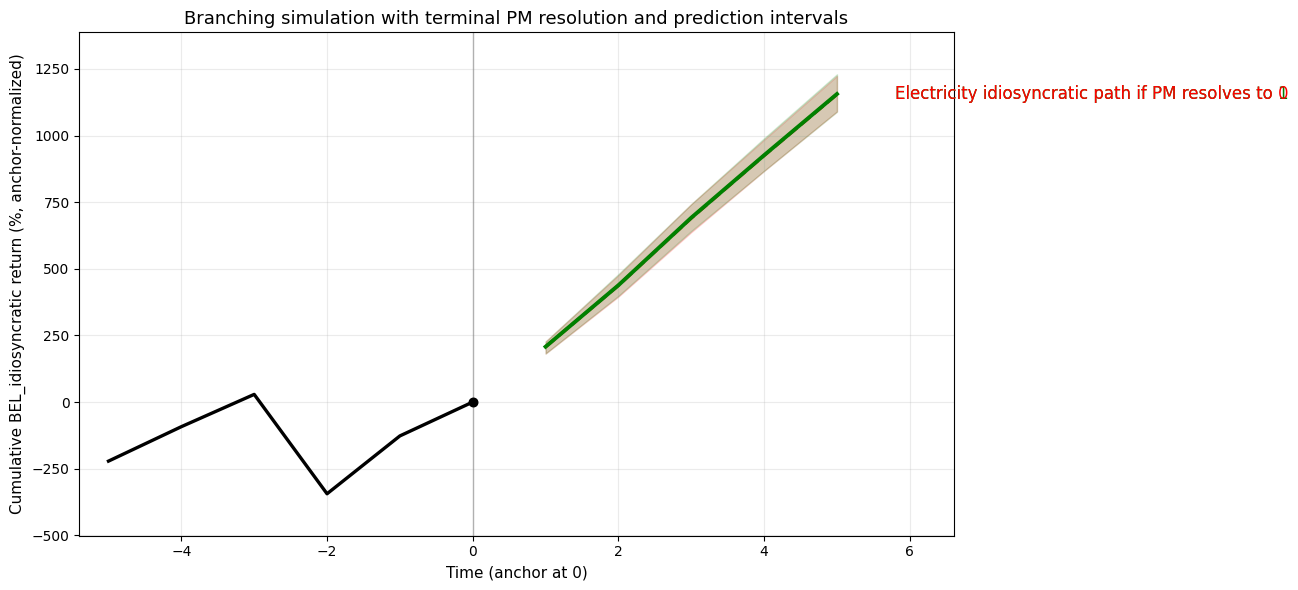

Monte Carlo branching paths displayed.
Green band: terminal PM resolution = 1 (Yes)
Red band: terminal PM resolution = 0 (No)
Bands represent 10th-90th percentile across 5000 simulations


In [64]:
# ====================================================
# Monte Carlo branching visualization with conditional prediction intervals
# Anchor-normalized cumulative electricity idiosyncratic returns by terminal PM state
# ====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_mc_vars = [
    "idio_paths",
    "terminal_vals",
    "sim_df_mc",
    "t0_pos",
    "horizon",
    "y_idio_col",
]
missing_mc_vars = [v for v in required_mc_vars if v not in globals()]
if missing_mc_vars:
    raise ValueError(
        f"Missing variables from Monte Carlo cell: {missing_mc_vars}. "
        "Run the 'Monte Carlo' cell first."
    )

# Historical idiosyncratic returns up to anchor
hist_idio = sim_df_mc.iloc[:t0_pos + 1][y_idio_col].dropna().astype(float)
if hist_idio.empty:
    raise ValueError(
        f"Historical {y_idio_col} series is empty up to anchor."
    )

# Keep short recent context and normalize so anchor = 0
pre_hist = min(6, len(hist_idio))
hist_tail = hist_idio.tail(pre_hist).to_numpy()
hist_cum = np.cumsum(hist_tail)
hist_rel = hist_cum - hist_cum[-1]
hist_x = np.arange(-len(hist_rel) + 1, 1)

# Monte Carlo cumulative paths by terminal condition (in %, anchor at 0)
cum_paths_pp = np.cumsum(idio_paths, axis=1)
mask_resolve_1 = terminal_vals.astype(int) == 1
mask_resolve_0 = terminal_vals.astype(int) == 0

if mask_resolve_1.sum() == 0 or mask_resolve_0.sum() == 0:
    raise ValueError(
        "Need at least one path in each terminal state to draw branching visualization."
    )

# Compute conditional quantiles
res1_mean = cum_paths_pp[mask_resolve_1].mean(axis=0)
res1_lo = np.quantile(cum_paths_pp[mask_resolve_1], 0.10, axis=0)
res1_hi = np.quantile(cum_paths_pp[mask_resolve_1], 0.90, axis=0)

res0_mean = cum_paths_pp[mask_resolve_0].mean(axis=0)
res0_lo = np.quantile(cum_paths_pp[mask_resolve_0], 0.10, axis=0)
res0_hi = np.quantile(cum_paths_pp[mask_resolve_0], 0.90, axis=0)

future_x = np.arange(1, int(horizon) + 1)

# Create branching plot
fig, ax = plt.subplots(figsize=(13, 6))

# Historical pre-branch path (black)
ax.plot(hist_x, hist_rel, color="black", lw=2.4, zorder=5)
ax.scatter([0], [0.0], color="black", s=38, zorder=6)

# Terminal=0 branch (draw first so not hidden)
ax.plot(future_x, res0_mean, color="red", lw=2.3, ls="--", zorder=2)
ax.fill_between(future_x, res0_lo, res0_hi, color="red", alpha=0.16, zorder=1)

# Terminal=1 branch (draw second for visibility)
ax.plot(future_x, res1_mean, color="green", lw=2.8, zorder=4)
ax.fill_between(future_x, res1_lo, res1_hi, color="green", alpha=0.16, zorder=3)

# Branching divider
ax.axvline(0, color="gray", lw=1.0, alpha=0.55)

# Right-side labels with collision avoidance
label_x = future_x[-1] + 0.8
res1_y = float(res1_mean[-1])
res0_y = float(res0_mean[-1])
if abs(res1_y - res0_y) < 0.45:
    res1_y += 0.35
    res0_y -= 0.35

ax.text(
    label_x,
    res1_y,
    "Electricity idiosyncratic path if PM resolves to 1",
    color="green",
    fontsize=12,
    va="center",
)
ax.text(
    label_x,
    res0_y,
    "Electricity idiosyncratic path if PM resolves to 0",
    color="red",
    fontsize=12,
    va="center",
)

# Set axis limits with padding
y_vals = np.concatenate(
    [hist_rel, res1_lo, res1_hi, res0_lo, res0_hi, np.array([0.0])]
)
y_pad = max(0.5, 0.10 * (y_vals.max() - y_vals.min() + 1e-9))
ax.set_xlim(hist_x[0] - 0.4, label_x + 0.8)
ax.set_ylim(y_vals.min() - y_pad, y_vals.max() + y_pad)

ax.set_title(
    "Branching simulation with terminal PM resolution and prediction intervals",
    fontsize=13,
)
ax.set_xlabel("Time (anchor at 0)", fontsize=11)
ax.set_ylabel(
    f"Cumulative {y_idio_col} return (%, anchor-normalized)",
    fontsize=11,
)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Monte Carlo branching paths displayed.")
print(f"Green band: terminal PM resolution = 1 (Yes)")
print(f"Red band: terminal PM resolution = 0 (No)")
print(f"Bands represent 10th-90th percentile across {n_sims} simulations")


In [63]:
# Save key outputs to CSV for later reuse
import pandas as pd

exports = []

if "pm_hourly_last_month" in globals() and isinstance(pm_hourly_last_month, pd.DataFrame):
    f = "pm_hourly_last_month_pipeline_wide.csv"
    pm_hourly_last_month.to_csv(f, index=False)
    exports.append((f, pm_hourly_last_month.shape))

if "hourly_aligned" in globals() and isinstance(hourly_aligned, pd.DataFrame):
    f = "hourly_aligned_with_pm_window.csv"
    hourly_aligned.to_csv(f, index=False)
    exports.append((f, hourly_aligned.shape))

if "hourly_aligned_diff" in globals() and isinstance(hourly_aligned_diff, pd.DataFrame):
    f = "hourly_aligned_with_pm_window_differences.csv"
    hourly_aligned_diff.to_csv(f, index=False)
    exports.append((f, hourly_aligned_diff.shape))

if "hourly_aligned_pct" in globals() and isinstance(hourly_aligned_pct, pd.DataFrame):
    f = "hourly_aligned_with_pm_window_pct_changes.csv"
    hourly_aligned_pct.to_csv(f, index=False)
    exports.append((f, hourly_aligned_pct.shape))

if "binomial_scenario_summary" in globals() and isinstance(binomial_scenario_summary, pd.DataFrame):
    f = "binomial_scenario_summary_100obs.csv"
    binomial_scenario_summary.to_csv(f, index=False)
    exports.append((f, binomial_scenario_summary.shape))

if "binomial_terminal_summary" in globals() and isinstance(binomial_terminal_summary, pd.DataFrame):
    f = "binomial_terminal_summary_100obs.csv"
    binomial_terminal_summary.to_csv(f, index=False)
    exports.append((f, binomial_terminal_summary.shape))

if "mc_elec_idio_results" in globals() and isinstance(mc_elec_idio_results, pd.DataFrame):
    f = "mc_elec_idio_results_100obs.csv"
    mc_elec_idio_results.to_csv(f, index=False)
    exports.append((f, mc_elec_idio_results.shape))

if "mc_elec_idio_summary" in globals() and isinstance(mc_elec_idio_summary, pd.DataFrame):
    f = "mc_elec_idio_summary_100obs.csv"
    mc_elec_idio_summary.to_csv(f, index=False)
    exports.append((f, mc_elec_idio_summary.shape))

if "mc_results" in globals() and isinstance(mc_results, pd.DataFrame):
    f = "mc_results_full_100obs.csv"
    mc_results.to_csv(f, index=False)
    exports.append((f, mc_results.shape))

print("Saved CSV exports:")
for name, shape in exports:
    print(f"- {name}: {shape}")

if not exports:
    print("No exportable dataframes found. Run upstream cells first.")

Saved CSV exports:
- pm_hourly_last_month_pipeline_wide.csv: (50, 3)
- hourly_aligned_with_pm_window.csv: (635, 10)
- hourly_aligned_with_pm_window_differences.csv: (634, 9)
- hourly_aligned_with_pm_window_pct_changes.csv: (634, 7)
- binomial_scenario_summary_100obs.csv: (4, 10)
- binomial_terminal_summary_100obs.csv: (2, 5)
- mc_elec_idio_results_100obs.csv: (5000, 6)
- mc_elec_idio_summary_100obs.csv: (2, 9)
- mc_results_full_100obs.csv: (5000, 6)


In [11]:
# Compare factor-model explanatory power: weather-only vs weather+load
import numpy as np
import pandas as pd

if "hourly_aligned" not in globals() or not isinstance(hourly_aligned, pd.DataFrame):
    raise ValueError("hourly_aligned is required. Run the aligned dataset and factor-model cells first.")

base_target = "Country Hourly - Belgium"
weather_cols = ["BE Temp (C)", "BE Precipitation (mm)", "BE Wind Speed (km/h)"]
load_cols = ["pct_BE_actual_load", "pct_BE_forecast_load", "pct_BE_forecast_vs_actual_load"]

missing_weather = [c for c in weather_cols + [base_target] if c not in hourly_aligned.columns]
if missing_weather:
    raise ValueError(f"Missing weather/target columns in hourly_aligned: {missing_weather}")

def fit_pca_factor_model(df, target_col, factor_cols, label):
    work = df[["timestamp", target_col] + factor_cols].copy().sort_values("timestamp").reset_index(drop=True)
    work[factor_cols + [target_col]] = work[factor_cols + [target_col]].interpolate(method="linear", limit_area="inside")
    work["BEL_returns"] = work[target_col].pct_change() * 100
    ret_df = work[["timestamp", "BEL_returns"] + factor_cols].dropna().copy()

    if len(ret_df) < 5:
        return {"label": label, "n_obs": len(ret_df), "error": "too_few_rows"}

    std = ret_df[factor_cols].std(axis=0, ddof=0)
    active = std[std > 0].index.tolist()
    if not active:
        return {"label": label, "n_obs": len(ret_df), "error": "no_active_factors"}

    X = ret_df[active]
    y = ret_df["BEL_returns"]
    Xz = ((X - X.mean(axis=0)) / X.std(axis=0, ddof=0)).dropna().copy()
    y = y.loc[Xz.index]

    U, S, _ = np.linalg.svd(Xz.to_numpy(), full_matrices=False)
    explained = (S**2) / np.sum(S**2)
    n_components = max(1, int(np.searchsorted(np.cumsum(explained), 0.95) + 1))
    scores = U * S
    X_pca = scores[:, :n_components]

    X_design = np.column_stack([np.ones(len(X_pca)), X_pca])
    coef = np.linalg.lstsq(X_design, y.to_numpy(), rcond=None)[0]
    fitted = X_design @ coef
    resid = y.to_numpy() - fitted

    rss = float(np.sum(resid**2))
    tss = float(np.sum((y.to_numpy() - y.mean())**2))
    r2 = float(1 - rss / tss) if tss > 0 else float("nan")
    n = len(y)
    k = n_components
    adj_r2 = float(1 - (1 - r2) * (n - 1) / (n - k - 1)) if n > (k + 1) else float("nan")

    return {
        "label": label,
        "n_obs": int(n),
        "n_active_factors": int(len(active)),
        "n_components": int(n_components),
        "r2": r2,
        "adj_r2": adj_r2,
        "resid_std": float(np.std(resid, ddof=1)) if n > 1 else float("nan"),
        "active_factors": active,
    }

results = []
results.append(fit_pca_factor_model(hourly_aligned, base_target, weather_cols, "Weather only"))

available_load_cols = [c for c in load_cols if c in hourly_aligned.columns]
if len(available_load_cols) == len(load_cols):
    results.append(
        fit_pca_factor_model(
            hourly_aligned,
            base_target,
            weather_cols + load_cols,
            "Weather + load factors",
        )
    )
else:
    print("Skipping weather+load comparison because load factors are missing:", [c for c in load_cols if c not in hourly_aligned.columns])

comp = pd.DataFrame([{k: v for k, v in r.items() if k != "active_factors"} for r in results])
display(comp)

for r in results:
    print("\n", r["label"], sep="")
    if "error" in r:
        print("Error:", r["error"])
        continue
    print("Active factors:", r["active_factors"])
    print(f"R2: {r['r2']:.4f} | Adj R2: {r['adj_r2']:.4f} | Residual std: {r['resid_std']:.4f}")

,label,n_obs,n_active_factors,n_components,r2,adj_r2,resid_std
0,Weather only,49,2,2,0.110590,0.071920,36.092632
1,Weather + load factors,49,5,4,0.170734,0.095347,34.850937



Weather only
Active factors: ['BE Temp (C)', 'BE Wind Speed (km/h)']
R2: 0.1106 | Adj R2: 0.0719 | Residual std: 36.0926

Weather + load factors
Active factors: ['BE Temp (C)', 'BE Wind Speed (km/h)', 'pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load']
R2: 0.1707 | Adj R2: 0.0953 | Residual std: 34.8509
